<div style="display: flex; background-color: #7b002c; border-radius: 48px;">
<div style="margin: auto; padding: 48px; color: white; font-size: 48px" align="center">
<strong>🍷 BottleNeck 🍷</strong>
<br/>
Analyse du stock et des ventes
</div>
</div>

<div style="font-size: 42px;">
🤖 Amélioration du notebook assistée par IA
</div>

🐻‍❄️ Analyse exploratoire optimisée avec [Polars](https://pola.rs/)

🐧 Analyse statistique approfondie avec [Pingouin](https://pingouin-stats.org/)

# Import des librairies et paramètres généraux

## Import des librairies

In [1]:
import numpy as np

In [2]:
import pandas as pd
# import openpyxl # required by Pandas to read/write Excel files

In [3]:
import polars as pl
# import fastexcel  # required by Polars to read  Excel files
# import xlsxwriter # required by Polars to write Excel files

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
import scipy
# import statsmodels # used by plotly for trendline
import pingouin as pg

## Fonctions pour les tests statistiques

In [6]:
def test_quanti_quanti(df, *, x, y, alpha=0.05):
    assert x in df.columns, f"⚠️ La variable x={x} n'existe pas."
    assert y in df.columns, f"⚠️ La variable y={y} n'existe pas."
    df = df[[x,y]].select_dtypes(np.number)
    assert x in df.columns, f"⚠️ La variable x={x} n'est pas quantitative."
    assert y in df.columns, f"⚠️ La variable y={y} n'est pas quantitative."
    x_is_normal = pg.normality(df[x], method="shapiro", alpha=alpha).iloc[0].normal
    y_is_normal = pg.normality(df[y], method="shapiro", alpha=alpha).iloc[0].normal
    print(f"ℹ️ [Shapiro-Wilk] La variable x={x} {'suit' if x_is_normal else 'ne suit pas'} une distribution normale.")
    print(f"ℹ️ [Shapiro-Wilk] La variable y={y} {'suit' if y_is_normal else 'ne suit pas'} une distribution normale.")
    if x_is_normal and y_is_normal:
        method = "pearson"
        r_display = "r"
    else:
        method = "spearman"
        r_display = "ρ"
    corr_result = pg.corr(df[x], df[y], method=method).iloc[0]
    p_value = corr_result.p_val
    if p_value < alpha:
        print(f"✅ [Test de {method.title()}] Corrélation significative")
    else:
        print(f"❌ [Test de {method.title()}] Corrélation non significative")
    r = corr_result.r
    if r >= 0.75:
        print(f"🌖 [{r_display} = {r:.3f}] Corrélation positive forte")
    elif r >= 0.50:
        print(f"🌗 [{r_display} = {r:.3f}] Corrélation positive modérée")
    elif r >= 0.25:
        print(f"🌘 [{r_display} = {r:.3f}] Corrélation positive faible")
    elif r <= -.75:
        print(f"🌔 [{r_display} = {r:.3f}] Corrélation négative forte")
    elif r <= -.50:
        print(f"🌓 [{r_display} = {r:.3f}] Corrélation négative modérée")
    elif r <= -.25:
        print(f"🌒 [{r_display} = {r:.3f}] Corrélation négative faible")
    else:
        print(f"🌑 [{r_display} = {r:.3f}] Aucune corrélation")

In [7]:
def test_quali_quali(df, *, x, y, alpha=0.05):
    assert x in df.columns, f"⚠️ La variable x={x} n'existe pas."
    assert y in df.columns, f"⚠️ La variable y={y} n'existe pas."
    expected, observed, chi2_results = pg.chi2_independence(data=df, x=x, y=y)
    chi2_result = chi2_results.iloc[0]
    expected_min = expected.min().min()
    print(f"ℹ️ Taille du tableau de contingence = {expected.shape[0]}'×'{expected.shape[1]}")
    print(f"ℹ️ Fréquence attendue minimale = {expected_min}")
    if expected_min >= 5:
        p_value = chi2_result.pval
        if p_value < alpha:
            print("✅ [Test du χ²] Association significative")
        else:
            print("❌ [Test du χ²] Association non significative")
        v = chi2_result.cramer
        if v < 0.1:
            print(f"🌑 [V de Cramér = {v:.3f}] Effet négligeable")
        elif v < 0.3:
            print(f"🌘 [V de Cramér = {v:.3f}] Effet faible")
        elif v < 0.5:
            print(f"🌗 [V de Cramér = {v:.3f}] Effet modéré")
        else:
            print(f"🌖 [V de Cramér = {v:.3f}] Effet fort")
    elif observed.shape == (2, 2):
        stat, p_value = scipy.stats.fisher_exact(observed)
        if p_value < alpha:
            print("✅ [Test exact de Fisher] Association significative")
        else:
            print("❌ [Test exact de Fisher] Association non significative")
        print(f"ℹ️ Odds Ratio = {stat:.3f}")
        chi2 = chi2_result.chi2
        n = len(df)
        phi = np.sqrt(chi2 / n)
        if phi < 0.1:
            print(f"🌑 [ϕ = {phi:.3f}] Effet négligeable")
        elif phi < 0.3:
            print(f"🌘 [ϕ = {phi:.3f}] Effet faible")
        elif phi < 0.5:
            print(f"🌗 [ϕ = {phi:.3f}] Effet modéré")
        else:
            print(f"🌖 [ϕ = {phi:.3f}] Effet fort")
    else:
        print("⚠️ Aucun test statistique courant disponible")
    return { "expected": expected, "observed": observed }

In [8]:
def test_quanti_binary(df, *, quanti, binary, alpha=0.05):
    assert quanti in df.columns, f"⚠️ La variable quanti={quanti} n'existe pas."
    assert binary in df.columns, f"⚠️ La variable binary={binary} n'existe pas."
    keys = np.sort(df[binary].unique())
    assert len(keys) == 2, f"⚠️ La variable qualitative n'est pas binaire ({len(keys)} groupe[s] trouvé[s])."
    normal_test_result = pg.normality(df, dv=quanti, group=binary, method="shapiro", alpha=alpha)
    print(f"ℹ️ [Shapiro-Wilk] {normal_test_result.normal.sum()}/2 groupes suivent une distribution normale.")
    groups = { key: df[ (df[binary] == key) ][quanti].dropna() for key in keys }
    if normal_test_result.normal.all():
        t_test_result = pg.ttest(*groups.values()).iloc[0]
        p_value = t_test_result.p_val
        if p_value < alpha:
            print("✅ [Test T] Différence de groupes significative")
        else:
            print("❌ [Test T] Différence de groupes non significative")
        d = abs(t_test_result.cohen_d)
        if d < 0.2:
            print(f"🌑 [d de Cohen = {d:.3f}] Effet négligeable")
        elif d < 0.5:
            print(f"🌘 [d de Cohen = {d:.3f}] Effet faible")
        elif d < 0.8:
            print(f"🌗 [d de Cohen = {d:.3f}] Effet modéré")
        else:
            print(f"🌖 [d de Cohen = {d:.3f}] Effet fort")
    else:
        u_test_result = pg.mwu(*groups.values()).iloc[0]
        p_value = u_test_result.p_val
        if p_value < alpha:
            print("✅ [Test U de Mann-Whitney] Différence de groupes significative")
        else:
            print("❌ [Test U de Mann-Whitney] Différence de groupes non significative")
        r = abs(u_test_result.RBC)
        if r < 0.1:
            print(f"🌑 [rank-biserial correlation = {r:.3f}] Effet négligeable")
        elif r < 0.3:
            print(f"🌘 [rank-biserial correlation = {r:.3f}] Effet faible")
        elif r < 0.5:
            print(f"🌗 [rank-biserial correlation = {r:.3f}] Effet modéré")
        else:
            print(f"🌖 [rank-biserial correlation = {r:.3f}] Effet fort")

In [9]:
def test_quanti_multi(df, *, quanti, multi, alpha=0.05):
    assert quanti in df.columns, f"⚠️ La variable quanti={quanti} n'existe pas."
    assert multi in df.columns, f"⚠️ La variable multi={multi} n'existe pas."
    keys = np.sort(df[multi].unique())
    assert len(keys) >= 3, f"⚠️ La variable qualitative doit avoir au moins 3 groupes ({len(keys)} groupe[s] trouvé[s])."
    normal_test_result = pg.normality(df, dv=quanti, group=multi, method="shapiro", alpha=alpha)
    print(f"ℹ️ [Shapiro-Wilk] {normal_test_result['normal'].sum()}/{len(keys)} groupes suivent une distribution normale.")
    if normal_test_result.normal.all():
        anova_result = pg.anova(df, dv=quanti, between=multi, effsize='n2').iloc[0]
        p_value = anova_result.p_unc
        if p_value < alpha:
            print("✅ [ANOVA] Différence significative entre les groupes")
        else:
            print("❌ [ANOVA] Différence non significative entre les groupes")
        eta_2 = anova_result.n2
        if eta_2 < 0.01:
            print(f"🌑 [η² = {eta_2:.3f}] Effet négligeable")
        elif eta_2 < 0.06:
            print(f"🌘 [η² = {eta_2:.3f}] Effet faible")
        elif eta_2 < 0.14:
            print(f"🌗 [η² = {eta_2:.3f}] Effet modéré")
        else:
            print(f"🌖 [η² = {eta_2:.3f}] Effet fort")
    else:
        kw_result = pg.kruskal(df, dv=quanti, between=multi).iloc[0]
        p_value = kw_result.p_unc
        if p_value < alpha:
            print("✅ [Kruskal-Wallis] Différence significative entre les groupes")
        else:
            print("❌ [Kruskal-Wallis] Différence non significative entre les groupes")
        H = kw_result.H
        N = len(df)
        epsilon_2 = H/(N-1)
        if epsilon_2 < 0.01:
            print(f"🌑 [ε² = {epsilon_2:.3f}] Effet négligeable")
        elif epsilon_2 < 0.06:
            print(f"🌘 [ε² = {epsilon_2:.3f}] Effet faible")
        elif epsilon_2 < 0.14:
            print(f"🌗 [ε² = {epsilon_2:.3f}] Effet modéré")
        else:
            print(f"🌖 [ε² = {epsilon_2:.3f}] Effet fort")

## Autres fonctions et paramètres généraux

In [10]:
from pathlib import Path

In [11]:
data_path = Path("data")

In [12]:
# @see https://fr.wikipedia.org/wiki/Coefficient_de_Gini#Calcul_pratique
def indice_gini(values):
    a = np.sort(values)
    n = len(a)
    return (a.dot(range(1, n+1)) / a.sum() * 2 - n - 1) / n

# Chargement des fichiers Excel

In [13]:
df_erp = pl.read_excel(data_path/"input"/"erp.xlsx")

In [14]:
df_web = pl.read_excel(data_path/"input"/"web.xlsx")

Could not determine dtype for column 7, falling back to string
Could not determine dtype for column 11, falling back to string
Could not determine dtype for column 18, falling back to string
Could not determine dtype for column 22, falling back to string


In [15]:
df_liaison = pl.read_excel(data_path/"input"/"liaison.xlsx")

On observe que le moteur par défaut dans Polars (`calamine` fourni par `fastexcel`) échoue avec le fichier "web.xslx" concernant la détection automatique des types de colonnes.

C'est pourquoi le moteur `openpyxl` (utilisé par défaut dans Pandas) est utilisé à la place. 

In [16]:
df_erp = pl.read_excel(data_path/"input"/"erp.xlsx", engine="openpyxl")

/home/user/Workspace/venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [17]:
df_web = pl.read_excel(data_path/"input"/"web.xlsx", engine="openpyxl")

In [18]:
df_liaison = pl.read_excel(data_path/"input"/"liaison.xlsx", engine="openpyxl")

Les `UserWarning`s indiquent que `openpyxl` détecte des fonctionnalités spécifiques à Excel qui sont ignorées lors de la lecture des fichiers.

Cela n'est pas bloquant pour le bon chargement des données.

# Analyse exploratoire des fichiers

## Analyse exploratoire du fichier : erp.xlsx

In [19]:
print(f"Le tableau comporte {df_erp.height} observation(s) ou article(s).")
print(f"Le tableau comporte {df_erp.width} colonne(s).")

Le tableau comporte 825 observation(s) ou article(s).
Le tableau comporte 6 colonne(s).


In [20]:
df_erp.head(5)

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
i64,i64,f64,i64,str,f64
3847,1,24.2,16,"""instock""",12.88
3849,1,34.3,10,"""instock""",17.54
3850,1,20.8,0,"""outofstock""",10.64
4032,1,14.1,26,"""instock""",6.92
4039,1,46.0,3,"""outofstock""",23.77


In [21]:
df_erp.schema

Schema([('product_id', Int64),
        ('onsale_web', Int64),
        ('price', Float64),
        ('stock_quantity', Int64),
        ('stock_status', String),
        ('purchase_price', Float64)])

In [22]:
df_erp.null_count()

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


Il y a **825** produits référencés dans l'ERP. De plus, il n'y a *aucune valeur manquante*.

### Analyse de chaque colonne

#### Analyse de la colonne : product_id

In [23]:
any_duplicated = df_erp["product_id"].is_duplicated().any()
print(f"Doublons dans la colonne product_id ? {'OUI' if any_duplicated else 'NON'}")

Doublons dans la colonne product_id ? NON


La colonne `product_id` sert d'identifiant dans l'ERP. Il n'y a *aucun doublon*.

#### Analyse de la colonne : onsale_web

In [24]:
df_erp["onsale_web"].unique()

onsale_web
i64
0
1


In [25]:
df_erp["onsale_web"].sum()

716

La colonne `onsale_web` semble indiquer si un produit est actuellement en vente sur le site web (1 = true) ou non (0 = false). Il devrait y avoir **716** produits en vente.

#### Analyse de la colonne : price

In [26]:
print(f"Nombres d'articles avec un prix non renseigné = {df_erp["price"].is_null().sum()}")
print(f"Nombres d'articles avec un prix négatif = {(df_erp["price"] < 0).sum()}")
print(f"Nombres d'articles avec un prix nul = {(df_erp["price"] == 0).sum()}")

Nombres d'articles avec un prix non renseigné = 0
Nombres d'articles avec un prix négatif = 3
Nombres d'articles avec un prix nul = 0


In [27]:
print(f"Prix max = {df_erp["price"].max()}")
print(f"Prix min = {df_erp["price"].min()}")

Prix max = 225.0
Prix min = -20.0


In [28]:
df_erp.filter(pl.col("price")< 0)

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
i64,i64,f64,i64,str,f64
4233,0,-20.0,0,"""outofstock""",10.33
5017,0,-8.0,0,"""outofstock""",4.34
6594,0,-9.1,19,"""instock""",4.61


La colonne `price` contient des erreurs : **3** produits ont des prix négatifs.

#### Analyse de la colonne : stock_quantity

In [29]:
print(f"Nombres d'articles avec une quantité de stock non renseignée = {df_erp["stock_quantity"].is_null().sum()}")
print(f"Nombres d'articles avec une quantité de stock négative = {(df_erp["stock_quantity"] < 0).sum()}")
print(f"Nombres d'articles avec une quantité de stock nulle = {(df_erp["stock_quantity"] == 0).sum()}")

Nombres d'articles avec une quantité de stock non renseignée = 0
Nombres d'articles avec une quantité de stock négative = 2
Nombres d'articles avec une quantité de stock nulle = 90


In [30]:
print(f"Quantité de stock max = {df_erp["stock_quantity"].max()}")
print(f"Quantité de stock min = {df_erp["stock_quantity"].min()}")

Quantité de stock max = 145
Quantité de stock min = -10


In [31]:
df_erp.filter(pl.col("stock_quantity") < 0)

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
i64,i64,f64,i64,str,f64
4973,0,10.0,-10,"""outofstock""",4.96
5700,1,44.5,-1,"""outofstock""",22.3


La colonne `stock_quantity` contient des erreurs : **2** produits ont un nombre d'unités en stock négatif.

#### Analyse de la colonne : stock_status

In [32]:
df_erp["stock_status"].unique()

stock_status
str
"""outofstock"""
"""instock"""


In [33]:
(df_erp["stock_status"] == "instock").sum()

733

La colonne `stock_status` semble indiquer si un produit est présent en stock (instock) ou non (outofstock).

#### Analyse de la colonne : purchase_price

In [34]:
print(f"Nombres d'articles avec un prix fournisseur non renseigné = {df_erp["purchase_price"].is_null().sum()}")
print(f"Nombres d'articles avec un prix fournisseur négatif = {(df_erp["purchase_price"] < 0).sum()}")
print(f"Nombres d'articles avec un prix fournisseur nul = {(df_erp["purchase_price"] == 0).sum()}")

Nombres d'articles avec un prix fournisseur non renseigné = 0
Nombres d'articles avec un prix fournisseur négatif = 0
Nombres d'articles avec un prix fournisseur nul = 0


In [35]:
print(f"Prix fournisseur max = {df_erp["purchase_price"].max()}")
print(f"Prix fournisseur min = {df_erp["purchase_price"].min()}")

Prix fournisseur max = 137.81
Prix fournisseur min = 2.74


La colonne `purchase_price` semble ne contenir *aucune erreur* (tous les prix fournisseur sont positifs).

### Analyse de la cohérence entre colonnes

#### Incohérences entre price et purchase_price

In [36]:
df_erp.filter( ~( (0 < pl.col("purchase_price")) & (pl.col("purchase_price") < pl.col("price")) ) )

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
i64,i64,f64,i64,str,f64
4233,0,-20.0,0,"""outofstock""",10.33
4355,1,12.65,97,"""instock""",77.48
4864,0,8.3,0,"""outofstock""",9.99
5017,0,-8.0,0,"""outofstock""",4.34
6324,0,92.0,18,"""instock""",99.0
6594,0,-9.1,19,"""instock""",4.61
7196,0,31.0,55,"""instock""",31.2


Il y a **7** produits pour lesquels le prix de vente est inférieur au prix fournisseur (marge négative).
Parmi eux, on retrouve les **3** produits avec un prix de vente négatif.

#### Incohérences entre stock_quantity et stock_status

In [37]:
df_erp.filter( ((pl.col("stock_quantity") == 0) != (pl.col("stock_status") == "outofstock")) )

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
i64,i64,f64,i64,str,f64
4039,1,46.0,3,"""outofstock""",23.77
4885,1,18.7,0,"""instock""",9.66
4973,0,10.0,-10,"""outofstock""",4.96
5700,1,44.5,-1,"""outofstock""",22.3


En plus des **2** produits avec un nombre d'unités en stock négatif, on détecte **2** autres problèmes.

- 3 unités en stock pour le produit 4039, pourtant marqué en rupture de stock
- 0 unités en stock pour le produit 4885, pourtant marqué en stock

## Analyse exploratoire du fichier : web.xlsx

In [38]:
print(f"Le tableau comporte {df_web.height} observation(s) ou article(s).")
print(f"Le tableau comporte {df_web.width} colonne(s).")

Le tableau comporte 1513 observation(s) ou article(s).
Le tableau comporte 29 colonne(s).


In [39]:
df_web.schema

Schema([('sku', String),
        ('virtual', Int64),
        ('downloadable', Int64),
        ('rating_count', Int64),
        ('average_rating', Int64),
        ('total_sales', Int64),
        ('tax_status', String),
        ('tax_class', Null),
        ('post_author', Int64),
        ('post_date', Datetime(time_unit='us', time_zone=None)),
        ('post_date_gmt', Datetime(time_unit='us', time_zone=None)),
        ('post_content', Null),
        ('product_type', String),
        ('post_title', String),
        ('post_excerpt', String),
        ('post_status', String),
        ('comment_status', String),
        ('ping_status', String),
        ('post_password', Null),
        ('post_name', String),
        ('post_modified', Datetime(time_unit='us', time_zone=None)),
        ('post_modified_gmt', Datetime(time_unit='us', time_zone=None)),
        ('post_content_filtered', Null),
        ('post_parent', Int64),
        ('guid', String),
        ('menu_order', Int64),
        ('post_ty

In [40]:
df_web.null_count()

sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
85,0,0,0,83,83,797,1513,83,83,83,1513,84,83,797,83,83,83,1513,83,83,83,1513,83,83,83,83,799,83


### Structure générale : produits et images

En ouvrant le fichier web.xlsx dans Excel, on remarque que chaque ligne semble correspondre à des documents dans une collection (e.g. base de données WordPress).

La colonne GUID désigne certainement un identifiant unique global du document dans la collection.

Hormis quelques lignes vides, on distingue deux types de documents indiqués dans la colonne `post_type` :

- "product" (description dans la colonne `post_excerpt`)

- "attachment" (image en pièce jointe)

Les blocs ci-dessous permettent de vérifier ces propriétés.

In [41]:
any_duplicated = df_web.filter(
    pl.col("sku").is_not_null()
).select(
    pl.col("guid").is_duplicated().any()
).item()
print(f"Doublons dans la colonne guid (sauf vide) ? {'OUI' if any_duplicated else 'NON'}")

Doublons dans la colonne guid (sauf vide) ? NON


In [42]:
for post_type in df_web["post_type"].unique():
    condition = (pl.col("post_type") == post_type) if post_type is not None else pl.col("post_type").is_null()
    post_mime_types = df_web.filter(condition)["post_mime_type"].unique()
    print(f"Le type {post_type} est relié au(x) type(s) MIME :", *post_mime_types)

Le type attachment est relié au(x) type(s) MIME : image/jpeg
Le type product est relié au(x) type(s) MIME : None
Le type None est relié au(x) type(s) MIME : None


In [43]:
df_web_product = df_web.filter( pl.col("post_type") == "product" )
print(f"Le fichier web.xlsx contient {df_web_product.shape[0]} lignes de type : produit")

Le fichier web.xlsx contient 716 lignes de type : produit


In [44]:
df_web_image = df_web.filter( pl.col("post_type") == "attachment" )
print(f"Le fichier web.xlsx contient {df_web_image.shape[0]} lignes de type : image")

Le fichier web.xlsx contient 714 lignes de type : image


In [45]:
df_web_empty = df_web.filter( df_web["post_type"].is_null() )
print(f"Le fichier web.xlsx contient {df_web_empty.shape[0]} lignes vides.")

Le fichier web.xlsx contient 83 lignes vides.


In [46]:
df_web_empty.head(5)

sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
str,i64,i64,i64,i64,i64,str,null,i64,datetime[μs],datetime[μs],null,str,str,str,str,str,str,null,str,datetime[μs],datetime[μs],null,i64,str,i64,str,str,i64
null,0,0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
null,0,0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
null,0,0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
null,0,0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
null,0,0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null


In [47]:
df_web_empty_count = df_web_empty.select( pl.all().n_unique() )
df_web_empty_count

sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [48]:
all_unique = (df_web_empty_count == 1).to_numpy().all()
print(f"Pour toutes les lignes où post_type est vide, les valeurs sont-elles toutes nulles ou vides ? {'OUI' if all_unique else 'NON'}")

Pour toutes les lignes où post_type est vide, les valeurs sont-elles toutes nulles ou vides ? OUI


### Suppression des colonnes sans information en ligne

En ouvrant le fichier web.xlsx dans Excel, on remarque également que certaines colonnes contiennent des valeurs identiques.

Les blocs ci-dessous permettent de le vérifier et de supprimer les colonnes qui n'apportent pas d'information pour chaque produit/image.

In [49]:
print("Suppression des colonnes avec la même valeur pour les produits")
for colonne in list(df_web_product.columns):
    if df_web_product[colonne].n_unique() == 1:
        print(f"    - {colonne} : {df_web_product[colonne].first()}")
        df_web_product = df_web_product.drop(colonne)
df_web_product.schema

Suppression des colonnes avec la même valeur pour les produits
    - virtual : 0
    - downloadable : 0
    - rating_count : 0
    - average_rating : 0
    - tax_status : taxable
    - tax_class : None
    - post_content : None
    - post_status : publish
    - comment_status : closed
    - ping_status : closed
    - post_password : None
    - post_content_filtered : None
    - post_parent : 0
    - menu_order : 0
    - post_type : product
    - post_mime_type : None
    - comment_count : 0


Schema([('sku', String),
        ('total_sales', Int64),
        ('post_author', Int64),
        ('post_date', Datetime(time_unit='us', time_zone=None)),
        ('post_date_gmt', Datetime(time_unit='us', time_zone=None)),
        ('product_type', String),
        ('post_title', String),
        ('post_excerpt', String),
        ('post_name', String),
        ('post_modified', Datetime(time_unit='us', time_zone=None)),
        ('post_modified_gmt', Datetime(time_unit='us', time_zone=None)),
        ('guid', String)])

In [50]:
print("Suppression des colonnes avec la même valeur pour les images")
for colonne in list(df_web_image.columns):
    if df_web_image[colonne].n_unique() == 1:
        print(f"    - {colonne} : {df_web_image[colonne].first()}")
        df_web_image = df_web_image.drop(colonne)
df_web_image.schema

Suppression des colonnes avec la même valeur pour les images
    - virtual : 0
    - downloadable : 0
    - rating_count : 0
    - average_rating : 0
    - tax_status : None
    - tax_class : None
    - post_content : None
    - post_excerpt : None
    - post_status : publish
    - comment_status : closed
    - ping_status : closed
    - post_password : None
    - post_content_filtered : None
    - post_parent : 0
    - menu_order : 0
    - post_type : attachment
    - post_mime_type : image/jpeg
    - comment_count : 0


Schema([('sku', String),
        ('total_sales', Int64),
        ('post_author', Int64),
        ('post_date', Datetime(time_unit='us', time_zone=None)),
        ('post_date_gmt', Datetime(time_unit='us', time_zone=None)),
        ('product_type', String),
        ('post_title', String),
        ('post_name', String),
        ('post_modified', Datetime(time_unit='us', time_zone=None)),
        ('post_modified_gmt', Datetime(time_unit='us', time_zone=None)),
        ('guid', String)])

La colonne `post_excerpt` est inutile pour l'analyse.

In [51]:
df_web_product = df_web_product.drop("post_excerpt")

Les mêmes colonnes ont été supprimées dans `df_web_product` et `df_web_image`.

In [52]:
assert df_web_product.columns == df_web_image.columns

### Jonction entre produits et images

Vérifions que le SKU (Stock Keeping Unit = unité de gestion des stocks) sert d'identifiant.

In [53]:
any_duplicated = df_web_product["sku"].is_duplicated().any()
print(f"Doublons dans la colonne sku pour les produits ? {'OUI' if any_duplicated else 'NON'}")

Doublons dans la colonne sku pour les produits ? OUI


D'où viennent les doublons ?

In [54]:
df_web_product.null_count()

sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_name,post_modified,post_modified_gmt,guid
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
2,0,0,0,0,1,0,0,0,0,0


On observe que, parmi les **716** lignes de type produit, **2** ont une valeur manquante pour le SKU.

Refaisons le test sans les **2** valeurs manquantes.

In [55]:
any_duplicated = df_web_product.filter( pl.col("sku").is_not_null() )["sku"].is_duplicated().any()
print(f"Doublons dans la colonne sku pour les produits (sauf vide) ? {'OUI' if any_duplicated else 'NON'}")

Doublons dans la colonne sku pour les produits (sauf vide) ? NON


In [56]:
any_duplicated = df_web_image["sku"].is_duplicated().any()
print(f"Doublons dans la colonne sku pour les images ? {'OUI' if any_duplicated else 'NON'}")

Doublons dans la colonne sku pour les images ? NON


Réalisons une jointure externe de `df_web_product` et `df_web_image`.

In [57]:
df_web = df_web_product.join(df_web_image, on="sku", suffix="__image", validate="1:1")
df_web.schema

Schema([('sku', String),
        ('total_sales', Int64),
        ('post_author', Int64),
        ('post_date', Datetime(time_unit='us', time_zone=None)),
        ('post_date_gmt', Datetime(time_unit='us', time_zone=None)),
        ('product_type', String),
        ('post_title', String),
        ('post_name', String),
        ('post_modified', Datetime(time_unit='us', time_zone=None)),
        ('post_modified_gmt', Datetime(time_unit='us', time_zone=None)),
        ('guid', String),
        ('total_sales__image', Int64),
        ('post_author__image', Int64),
        ('post_date__image', Datetime(time_unit='us', time_zone=None)),
        ('post_date_gmt__image', Datetime(time_unit='us', time_zone=None)),
        ('product_type__image', String),
        ('post_title__image', String),
        ('post_name__image', String),
        ('post_modified__image', Datetime(time_unit='us', time_zone=None)),
        ('post_modified_gmt__image', Datetime(time_unit='us', time_zone=None)),
        ('gu

In [58]:
df_web.shape

(714, 21)

Le paramètre `validate="1:1"` assure que chaque produit et chaque image n'apparaît pas plus d'une fois dans la jointure.

Puisqu'il y a **714** lignes dans la jointure, cela signifie que :

- Parmi les **716** produits, *certains* (**2**) ne sont associés à aucune image.
- *Toutes* les **714** images sont associées à un produit.

In [59]:
df_web_product_only = df_web_product.join(df_web_image, on="sku", how="anti")
df_web_product_only

sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_name,post_modified,post_modified_gmt,guid
str,i64,i64,datetime[μs],datetime[μs],str,str,str,datetime[μs],datetime[μs],str
null,-56,2,2018-08-08 11:23:43,2018-08-08 09:23:43,"""Vin""","""Pierre Jean Villa Condrieu Jar…","""pierre-jean-villa-condrieu-sus…",2019-11-02 13:24:01,2019-11-02 12:24:01,"""https://www.bottle-neck.fr/?po…"
null,-17,2,2018-07-31 12:07:23,2018-07-31 10:07:23,"""Vin""","""Pierre Jean Villa Côte Rôtie F…","""pierre-jean-villa-cote-rotie-f…",2019-11-02 13:24:15,2019-11-02 12:24:15,"""https://www.bottle-neck.fr/?po…"


Les **2** produits sans image sont en fait ceux qui n'ont pas de SKU.
De plus, le nombre de ventes est négatif.

Il existe donc une bijection entre les **714** autres produits/images.

Nous retirons les **2** produits sans SKU de l'analyse, car il est impossible de les faire correspondre avec un produit référencé dans l'ERP.

In [60]:
df_web_image_only = df_web_image.join(df_web_product, on="sku", how="anti")
df_web_image_only

sku,total_sales,post_author,post_date,post_date_gmt,product_type,post_title,post_name,post_modified,post_modified_gmt,guid
str,i64,i64,datetime[μs],datetime[μs],str,str,str,datetime[μs],datetime[μs],str


### Cohérence des données entre produits et images

Regardons s'il y a des différences entre les informations fournies dans la ligne "produit" et la ligne "image" pour un même SKU.

In [61]:
for colonne in df_web_product.columns[1:]:
    cnt = (
          (df_web[colonne].is_null() != df_web[colonne + "__image"].is_null())
        | (df_web[colonne] != df_web[colonne + "__image"])
    ).sum()
    print(f"{cnt} SKU avec des valeurs différentes entre produit et image dans la colonne {colonne}")

4 SKU avec des valeurs différentes entre produit et image dans la colonne total_sales
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_author
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_date
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_date_gmt
1 SKU avec des valeurs différentes entre produit et image dans la colonne product_type
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_title
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_name
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_modified
0 SKU avec des valeurs différentes entre produit et image dans la colonne post_modified_gmt
714 SKU avec des valeurs différentes entre produit et image dans la colonne guid


Il y a des différences, ce qui est normal pour le GUID, mais pas pour les autres colonnes.

Commençons par éliminer les colonnes identiques et le GUID dont nous n'aurons pas besoin pour l'analyse.

In [62]:
for colonne in [ "post_author", "post_date", "post_date_gmt", "post_modified", "post_modified_gmt", "guid" ]:
    df_web = df_web.drop(colonne).drop(colonne + "__image")
df_web.schema

Schema([('sku', String),
        ('total_sales', Int64),
        ('product_type', String),
        ('post_title', String),
        ('post_name', String),
        ('total_sales__image', Int64),
        ('product_type__image', String),
        ('post_title__image', String),
        ('post_name__image', String)])

Il y a **4** SKU pour lesquels la colonne `total_sales` diffère entre produit et image.

In [63]:
df_web.filter( pl.col("total_sales") != pl.col("total_sales__image") )

sku,total_sales,product_type,post_title,post_name,total_sales__image,product_type__image,post_title__image,post_name__image
str,i64,str,str,str,i64,str,str,str
"""1366""",6,"""Champagne""","""Champagne Mailly Grand Cru Int…","""champagne-mailly-grand-cru-int…",116,"""Champagne""","""Champagne Mailly Grand Cru Int…","""champagne-mailly-grand-cru-int…"
"""15346""",2,"""Vin""","""Albert Mann Pinot Noir Grand H…","""albert-mann-pinot-noir-grand-h…",22,"""Vin""","""Albert Mann Pinot Noir Grand H…","""albert-mann-pinot-noir-grand-h…"
"""14950""",22,"""Vin""","""François Baur Pinot Noir Schli…","""francois-baur-pinot-noir-schli…",122,"""Vin""","""François Baur Pinot Noir Schli…","""francois-baur-pinot-noir-schli…"
"""14561""",11,"""Vin""","""Argentine Mendoza Alamos Torro…","""argentine-mendoza-alamos-torro…",111,"""Vin""","""Argentine Mendoza Alamos Torro…","""argentine-mendoza-alamos-torro…"


Il y a **1** SKU pour lequel la colonne `product_type` diffère entre produit et image.

In [64]:
df_web.filter( pl.col("product_type") != pl.col("product_type__image") )

sku,total_sales,product_type,post_title,post_name,total_sales__image,product_type__image,post_title__image,post_name__image
str,i64,str,str,str,i64,str,str,str


In [65]:
df_web.filter( pl.col("product_type").is_null() != pl.col("product_type__image").is_null() )

sku,total_sales,product_type,post_title,post_name,total_sales__image,product_type__image,post_title__image,post_name__image
str,i64,str,str,str,i64,str,str,str
"""bon-cadeau-25-euros""",7,null,"""Bon cadeau de 25€""","""bon-cadeau-de-25-euros""",7,"""Autre""","""Bon cadeau de 25€""","""bon-cadeau-de-25-euros"""


Il s'agit d'un produit spécial : un bon cadeau de 25€.
Le `product_type` est manquant côté produit, nous conservons la valeur "Autre" côté image.

In [66]:
for avant, apres in [ ("product_type", "type"), ("post_title", "title"), ("post_name", "name") ]:
    df_web = df_web.drop(avant).rename({avant+"__image":apres})
df_web = df_web.rename({"total_sales":"total_sales__product"})
df_web = df_web.select(["sku","type","title","name","total_sales__product","total_sales__image"]) # Permutation des colonnes
df_web.schema

Schema([('sku', String),
        ('type', String),
        ('title', String),
        ('name', String),
        ('total_sales__product', Int64),
        ('total_sales__image', Int64)])

### Analyse des colonnes restantes

In [67]:
df_web.select( pl.col("sku","type","title","name").n_unique() )

sku,type,title,name
u32,u32,u32,u32
714,7,711,714


#### Analyse de la colonne : SKU

La plupart des SKU sont des codes à 5 chiffres.
Ce n'est pas le cas pour le bon cadeau de 25€.
Regardons s'il existe d'autres SKU avec une forme différente.

In [68]:
df_web.filter( ~pl.col("sku").cast(str).str.contains(r"^[0-9]{5}$") )["sku"].unique().to_numpy()

array(['9636', '804', '791', '1366', '5646', '3506', '7818', '304',
       '3383', '3568', '8193', '7819', '812', '523', '9562', '807',
       '6616', '3510', '1364', '2534', '9937', 'bon-cadeau-25-euros',
       '7086', '8344', '7032', '3507', '1662', '802', '3509', '1360',
       '4679', '805', '13127-1', '2179', '38', '2361', '8365', '531',
       '793', '798', '41', '8463', '7033'], dtype=object)

In [69]:
df_web.filter( ~pl.col("sku").cast(str).str.contains(r"^[0-9]*$") )["sku"].unique().to_numpy()

array(['bon-cadeau-25-euros', '13127-1'], dtype=object)

In [70]:
df_web.filter( pl.col("sku").is_in(("13127-1", "13127")) )

sku,type,title,name,total_sales__product,total_sales__image
str,str,str,str,i64,i64
"""13127""","""Vin""","""Clos du Mont-Olivet Châteauneu…","""clos-du-mont-olivet-chateauneu…",5,5
"""13127-1""","""Vin""","""Clos du Mont-Olivet Châteauneu…","""clos-du-mont-olivet-chateauneu…",4,4


#### Analyse de la colonne : type

In [71]:
df_web.group_by("type").len()

type,len
str,u32
"""Champagne""",28
"""Vin""",658
"""Autre""",1
"""Cognac""",8
"""Huile d'olive""",3
"""Gin""",2
"""Whisky""",14


Hormis le bon cadeau de 25€ (Autre), il y a **6** catégories de produits.

#### Analyse de la colonne : title

In [72]:
df_web.filter( pl.col("title").is_duplicated() ).sort("title")

sku,type,title,name,total_sales__product,total_sales__image
str,str,str,str,i64,i64
"""13127-1""","""Vin""","""Clos du Mont-Olivet Châteauneu…","""clos-du-mont-olivet-chateauneu…",4,4
"""16034""","""Vin""","""Clos du Mont-Olivet Châteauneu…","""clos-du-mont-olivet-chateauneu…",8,8
"""15292""","""Vin""","""Domaine Hauvette IGP Alpilles …","""domaine-hauvette-igp-alpilles-…",8,8
"""16068""","""Vin""","""Domaine Hauvette IGP Alpilles …","""domaine-hauvette-igp-alpilles-…",5,5
"""14828""","""Vin""","""Marc Colin Et Fils Chassagne-M…","""marc-colin-et-fils-chassagne-m…",0,0
"""14000""","""Vin""","""Marc Colin Et Fils Chassagne-M…","""marc-colin-et-fils-chassagne-m…",4,4


Il y a **3** intitulés de produits qui apparaissent chacun **2** fois.
Cela sera expliqué par la suite (cf. 4.3).

## Analyse exploratoire du fichier : liaison.xlsx

In [73]:
print(f"Le tableau comporte {df_liaison.height} observation(s) ou article(s).")
print(f"Le tableau comporte {df_liaison.width} colonne(s).")

Le tableau comporte 825 observation(s) ou article(s).
Le tableau comporte 2 colonne(s).


In [74]:
df_liaison.schema

Schema([('id_web', String), ('product_id', Int64)])

In [75]:
df_liaison.null_count()

id_web,product_id
u32,u32
91,0


In [76]:
any_duplicated = df_liaison["product_id"].is_duplicated().any()
print(f"Doublons dans la colonne product_id ? {'OUI' if any_duplicated else 'NON'}")

Doublons dans la colonne product_id ? NON


In [77]:
any_duplicated = df_liaison["id_web"].drop_nulls().is_duplicated().any()
print(f"Doublons dans la colonne id_web (sauf vide) ? {'OUI' if any_duplicated else 'NON'}")

Doublons dans la colonne id_web (sauf vide) ? NON


La colonne `product_id` dans `df_liaison` semble correspondre à la colonne `product_id` dans `df_erp`.  
Les deux DataFrames comportent **825** lignes.

La colonne `id_web` dans `df_liaison` semble correspondre à la colonne `sku` dans `df_web`.
- `df_liaison` : **734** valeurs non vides + **91** valeurs vides
- `df_web` : **714** valeurs non vides + **2** valeurs vides (déjà retirées)

In [78]:
df_liaison.filter( ~pl.col("id_web").cast(str).str.contains(r"^[0-9]{5}$") )["id_web"].unique().to_numpy()

array(['1662', '7086', '7818', '3507', '9636', '798', '3509', '304',
       '807', '3510', '7033', '804', '791', '2179', '1364', '812', '41',
       '1366', '805', '2534', '3568', '8193', '7032', '6616', '2361',
       '4679', '7819', '38', '5646', '9937', '8463', '14680-1', '3506',
       '1360', 'bon-cadeau-25-euros', '3383', '802', '793', '523',
       '13127-1', '9562', '8344', '8365', '531'], dtype=object)

In [79]:
df_liaison.filter( ~pl.col("id_web").cast(str).str.contains(r"^[0-9]*$") )["id_web"].unique().to_numpy()

array(['14680-1', '13127-1', 'bon-cadeau-25-euros'], dtype=object)

In [80]:
df_web.filter( pl.col("sku").is_in(("14680-1", "14680")) )

sku,type,title,name,total_sales__product,total_sales__image
str,str,str,str,i64,i64
"""14680""","""Vin""","""Domaine Saint-Nicolas Fiefs Ve…","""domaine-saint-nicolas-fiefs-ve…",7,7


# Jonction des DataFrames 

## Jonction entre df_erp et df_liaison

In [81]:
df_merge = df_erp.join(df_liaison, on="product_id", validate="1:1")
df_merge.schema

Schema([('product_id', Int64),
        ('onsale_web', Int64),
        ('price', Float64),
        ('stock_quantity', Int64),
        ('stock_status', String),
        ('purchase_price', Float64),
        ('id_web', String)])

In [82]:
df_merge.shape

(825, 7)

Le résultat de cette jonction interne comporte **825** lignes.

Toutes les lignes de `df_erp` et `df_liaison` ont donc été préservées.

Cela est confirmé par le paramètre `validate="1:1"`.

## Jonction avec df_web

In [83]:
df_merge = df_merge.join(df_web, how="full", left_on="id_web", right_on="sku", validate="1:1")
df_merge.schema

Schema([('product_id', Int64),
        ('onsale_web', Int64),
        ('price', Float64),
        ('stock_quantity', Int64),
        ('stock_status', String),
        ('purchase_price', Float64),
        ('id_web', String),
        ('sku', String),
        ('type', String),
        ('title', String),
        ('name', String),
        ('total_sales__product', Int64),
        ('total_sales__image', Int64)])

In [84]:
df_merge.height

825

In [85]:
df_merge = df_merge.with_columns(
    pl.when(pl.col("sku"       ).is_null()).then(pl.lit("erp only"))
      .when(pl.col("product_id").is_null()).then(pl.lit("web only"))
      .otherwise(pl.lit("erp and web"))
      .alias("indicator")
)
df_merge.group_by("indicator").agg( pl.all().is_not_null().sum() )

indicator,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image
str,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""erp only""",111,111,111,111,111,111,20,0,0,0,0,0,0
"""erp and web""",714,714,714,714,714,714,714,714,714,714,714,714,714


Les **714** produits vendus sur le site web (avec un SKU) ont été conservés et associés à un produit dans l'ERP.

Les produits restants dans l'ERP (825 - 714 = **111**) sont tous présents.

Parmi ces derniers, il y a 734 - 714 = **20** produits avec un SKU qui ne correspond à aucun produit vendu sur le site web.

## Analyse de la cohérence entre colonnes

In [86]:
df_merge.filter( (pl.col("onsale_web") == 1) & (pl.col("indicator") == "erp only") )

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
i64,i64,f64,i64,str,f64,str,str,str,str,str,i64,i64,str
4594,1,144.0,0,"""outofstock""",87.36,null,null,null,null,null,null,null,"""erp only"""
5070,1,84.7,0,"""outofstock""",47.43,null,null,null,null,null,null,null,"""erp only"""
5075,1,43.3,0,"""outofstock""",21.7,null,null,null,null,null,null,null,"""erp only"""


Il y a **3** produits qui apparaissent en vente sur l'ERP mais qui n'apparaissent pas sur le site web.

In [87]:
df_merge.filter( (pl.col("onsale_web") == 0) & (pl.col("indicator") == "erp and web") )

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
i64,i64,f64,i64,str,f64,str,str,str,str,str,i64,i64,str
4200,0,5.8,33,"""instock""",3.12,"""16295""","""16295""","""Vin""","""Moulin de Gassac IGP Pays d'Hé…","""moulin-de-gassac-igp-pays-dher…",14,14,"""erp and web"""


Il y a **1** produit qui n'apparaît pas en vente sur l'ERP mais qui apparaît sur le site web.

In [88]:
df_merge.filter( pl.col("title").is_duplicated() & (pl.col("indicator") == "erp and web") ).sort("title")

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
i64,i64,f64,i64,str,f64,str,str,str,str,str,i64,i64,str
5465,1,54.8,12,"""instock""",28.6,"""16034""","""16034""","""Vin""","""Clos du Mont-Olivet Châteauneu…","""clos-du-mont-olivet-chateauneu…",8,8,"""erp and web"""
7247,1,54.8,6,"""instock""",27.18,"""13127-1""","""13127-1""","""Vin""","""Clos du Mont-Olivet Châteauneu…","""clos-du-mont-olivet-chateauneu…",4,4,"""erp and web"""
4288,1,26.7,26,"""instock""",14.48,"""15292""","""15292""","""Vin""","""Domaine Hauvette IGP Alpilles …","""domaine-hauvette-igp-alpilles-…",8,8,"""erp and web"""
6665,1,27.7,16,"""instock""",14.6,"""16068""","""16068""","""Vin""","""Domaine Hauvette IGP Alpilles …","""domaine-hauvette-igp-alpilles-…",5,5,"""erp and web"""
4597,1,61.6,7,"""instock""",33.42,"""14000""","""14000""","""Vin""","""Marc Colin Et Fils Chassagne-M…","""marc-colin-et-fils-chassagne-m…",4,4,"""erp and web"""
5544,1,61.6,0,"""outofstock""",31.51,"""14828""","""14828""","""Vin""","""Marc Colin Et Fils Chassagne-M…","""marc-colin-et-fils-chassagne-m…",0,0,"""erp and web"""


On comprend désormais pourquoi les **3** intitulés en doublon sont séparés : le prix fournisseur diffère.

In [89]:
df_merge.filter( (pl.col("sku") == "bon-cadeau-25-euros") )

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
i64,i64,f64,i64,str,f64,str,str,str,str,str,i64,i64,str
4954,1,25.0,23,"""instock""",13.3,"""bon-cadeau-25-euros""","""bon-cadeau-25-euros""","""Autre""","""Bon cadeau de 25€""","""bon-cadeau-de-25-euros""",7,7,"""erp and web"""


Le prix de vente du bon cadeau est bien de 25€.
On voit que 7 bons cadeau ont été vendus (total = 175€).

## Sélection des données pour les analyses

Pour réaliser les analyses, en plus des **2** produits sans SKU sur le site web, nous retirons les produits qui violent *une ou plusieurs* des règles suivantes.

- `indicator` = "erp and web"
- `onsale_web` = 1
- 0€ < `purchase_price` < `price`
- `stock_quantity` &geq; 0
- (`stock_quantity` = 0) et (`stock_status` = "outofstock") ont la même valeur.
- `total_sales` est entier positif ou nul qui a la même valeur dans `df_web_product` et `df_web_image`.

Le bon cadeau de 25€ est un produit à part, également exclus des analyses.

In [90]:
df_clean = df_merge.filter( (pl.col("indicator") == "erp and web") ).drop("indicator")
df_clean = df_clean.drop("id_web")
df_clean = df_clean.filter( (pl.col("onsale_web") == 1) ).drop("onsale_web")
df_clean = df_clean.filter( (pl.col("purchase_price") > 0) )
df_clean = df_clean.filter( (pl.col("purchase_price") < pl.col("price")) )
df_clean = df_clean.filter( (pl.col("stock_quantity") >= 0) )
df_clean = df_clean.filter( (pl.col("stock_quantity") == 0) == (pl.col("stock_status") == "outofstock") ).drop("stock_status")
df_clean = df_clean.with_columns( pl.col("total_sales__product").cast(int).alias("total_sales") )
df_clean = df_clean.filter( (pl.col("total_sales") >= 0) )
df_clean = df_clean.filter( (pl.col("total_sales") == pl.col("total_sales__product")) ).drop("total_sales__product")
df_clean = df_clean.filter( (pl.col("total_sales") == pl.col("total_sales__image"  )) ).drop("total_sales__image"  )
df_clean = df_clean.filter( (pl.col("sku") != "bon-cadeau-25-euros") )
df_clean.schema

Schema([('product_id', Int64),
        ('price', Float64),
        ('stock_quantity', Int64),
        ('purchase_price', Float64),
        ('sku', String),
        ('type', String),
        ('title', String),
        ('name', String),
        ('total_sales', Int64)])

In [91]:
df_clean.shape

(704, 9)

Il y a **704** produits qui respectent *tous* les critères précédents.

# Export au format Excel

## Export des données sélectionnées pour les analyses (**704** lignes)

In [92]:
df_clean.sort("product_id").write_excel(data_path/"output"/"données-analyses.xlsx")

## Export des données exclues des analyses (**123** lignes)

- 825 - 704 = **121** lignes qui violent *une ou plusieurs* conditions de sélection (cf. 4.4)
- **2** lignes pour les produits sans SKU dans `df_web_product`

In [93]:
df_other = df_merge.join(df_clean, on="product_id", how="anti").sort("product_id")
df_other.schema

Schema([('product_id', Int64),
        ('onsale_web', Int64),
        ('price', Float64),
        ('stock_quantity', Int64),
        ('stock_status', String),
        ('purchase_price', Float64),
        ('id_web', String),
        ('sku', String),
        ('type', String),
        ('title', String),
        ('name', String),
        ('total_sales__product', Int64),
        ('total_sales__image', Int64),
        ('indicator', String)])

In [94]:
df_other.shape

(121, 14)

In [95]:
df_web_sku_null = (
    df_web_product
    .filter( pl.col("sku").is_null() )
    .select(["sku","product_type","post_title","post_name","total_sales"])
    .rename({"product_type":"type","post_title":"title","post_name":"name","total_sales":"total_sales__product"})
    .with_columns( pl.lit("web only product").alias("indicator") )
)
df_web_sku_null

sku,type,title,name,total_sales__product,indicator
str,str,str,str,i64,str
null,"""Vin""","""Pierre Jean Villa Condrieu Jar…","""pierre-jean-villa-condrieu-sus…",-56,"""web only product"""
null,"""Vin""","""Pierre Jean Villa Côte Rôtie F…","""pierre-jean-villa-cote-rotie-f…",-17,"""web only product"""


In [96]:
df_other = pl.concat([ df_other, df_web_sku_null ], how="diagonal")
df_other.schema

Schema([('product_id', Int64),
        ('onsale_web', Int64),
        ('price', Float64),
        ('stock_quantity', Int64),
        ('stock_status', String),
        ('purchase_price', Float64),
        ('id_web', String),
        ('sku', String),
        ('type', String),
        ('title', String),
        ('name', String),
        ('total_sales__product', Int64),
        ('total_sales__image', Int64),
        ('indicator', String)])

In [97]:
df_other.shape

(123, 14)

In [98]:
df_other.tail(5)

product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,type,title,name,total_sales__product,total_sales__image,indicator
i64,i64,f64,i64,str,f64,str,str,str,str,str,i64,i64,str
7203,0,45.0,30,"""instock""",23.48,null,null,null,null,null,null,null,"""erp only"""
7204,0,45.0,9,"""instock""",24.18,null,null,null,null,null,null,null,"""erp only"""
7329,0,26.5,14,"""instock""",13.42,"""14680-1""",null,null,null,null,null,null,"""erp only"""
null,null,null,null,null,null,null,null,"""Vin""","""Pierre Jean Villa Condrieu Jar…","""pierre-jean-villa-condrieu-sus…",-56,null,"""web only product"""
null,null,null,null,null,null,null,null,"""Vin""","""Pierre Jean Villa Côte Rôtie F…","""pierre-jean-villa-cote-rotie-f…",-17,null,"""web only product"""


In [99]:
df_other.write_excel(data_path/"output"/"données-à-vérifier.xlsx")

# Analyse univariée des prix de vente 

Les librairies statistiques et de visualisation ont une meilleure compatibilité avec Pandas que Polars.

In [100]:
df_clean = df_clean.to_pandas()
df_clean.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      704 non-null    int64  
 1   price           704 non-null    float64
 2   stock_quantity  704 non-null    int64  
 3   purchase_price  704 non-null    float64
 4   sku             704 non-null    str    
 5   type            704 non-null    str    
 6   title           704 non-null    str    
 7   name            704 non-null    str    
 8   total_sales     704 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 118.1 KB


## Exploration par la visualisation de données

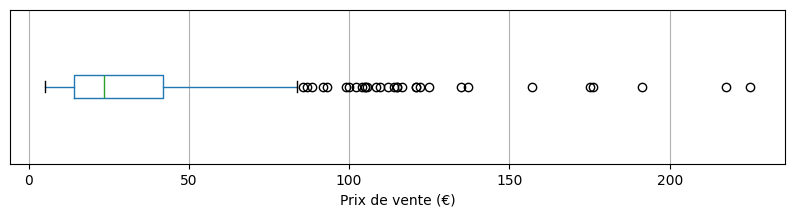

In [101]:
# @deprecated   vert=False                 Use orientation="horizontal" instead
# @bug          orientation="horizontal"   Warning + All xticks set to "price"
df_clean.boxplot("price", vert=False, figsize=(10,2))
plt.xlabel("Prix de vente (€)")
plt.yticks([])
plt.show()

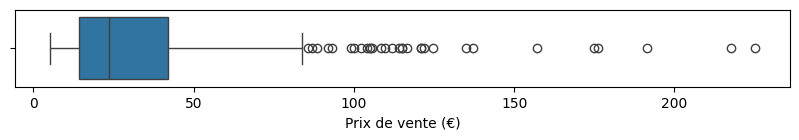

In [102]:
fig, ax = plt.subplots(figsize=(10,1))
sns.boxplot(df_clean, x="price", ax=ax)
plt.xlabel("Prix de vente (€)")
plt.show()

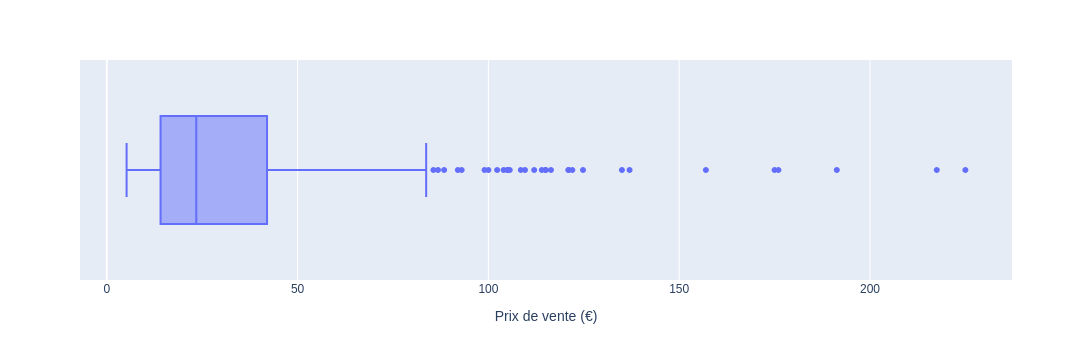

In [103]:
px.box(df_clean, x="price", hover_name="title", labels={"price":"Prix de vente (€)"})

## Exploration par l'utilisation de méthodes statistiques

### Identification par le Z-index

In [104]:
price_avg = df_clean["price"].mean()
print(f"Prix de vente moyen = {price_avg:_.2f}€")

Prix de vente moyen = 32.37€


In [105]:
price_std = df_clean["price"].std()
print(f"Ecart type du prix de vente = {price_std:_.2f}€")

Ecart type du prix de vente = 27.69€


In [106]:
zscore = (df_clean["price"] - price_avg) / price_std
zscore_scipy = pd.Series(scipy.stats.zscore(df_clean["price"]))
print(f"Ecart max entre les Z-scores de [Pandas only] et [Pandas + SciPy] : {(zscore - zscore_scipy).abs().max():_.2e}")

Ecart max entre les Z-scores de [Pandas only] et [Pandas + SciPy] : 4.95e-03


In [107]:
threshold = 3
above = df_clean["price"][ (zscore >= threshold) ].min()
below = df_clean["price"][ (zscore <= threshold) ].max()
print(f"Z-score({below:_.2f}€) <= {threshold} <= Z-score({above:_.2f}€) [Pandas only]")
above = df_clean["price"][ (zscore_scipy >= threshold) ].min()
below = df_clean["price"][ (zscore_scipy <= threshold) ].max()
print(f"Z-score({below:_.2f}€) <= {threshold} <= Z-score({above:_.2f}€) [Pandas + SciPy]")

Z-score(115.00€) <= 3 <= Z-score(116.40€) [Pandas only]
Z-score(115.00€) <= 3 <= Z-score(116.40€) [Pandas + SciPy]


In [108]:
den = zscore.shape[0]
num = (zscore.abs() > 3).sum()
print(f"Prix de vente outliers : {num}/{den} = {100.*num/den:.2f}% [Pandas only]")
num = (zscore_scipy.abs() > 3).sum()
print(f"Prix de vente outliers : {num}/{den} = {100.*num/den:.2f}% [Pandas + SciPy]")

Prix de vente outliers : 13/704 = 1.85% [Pandas only]
Prix de vente outliers : 13/704 = 1.85% [Pandas + SciPy]


### Identification par l'intervalle interquartile

In [109]:
price_describe = df_clean["price"].describe()
price_describe

count    704.000000
mean      32.373438
std       27.690017
min        5.200000
25%       14.100000
50%       23.450000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [110]:
prix_seuil = price_describe["75%"] + 1.5 * (price_describe["75%"] - price_describe["25%"])
print(f"Prix seuil = {prix_seuil:_.2f}€")

Prix seuil = 83.85€


In [111]:
num = (df_clean["price"] > prix_seuil).sum()
den = df_clean.shape[0]
print(f"Prix outliers : {num}/{den} = {100.*num/den:.2f}%")

Prix outliers : 31/704 = 4.40%


In [112]:
df_clean.sort_values(by="price", ascending=False, inplace=True, ignore_index=True)
df_clean[:31]

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales
0,4352,225.0,0,137.81,15940,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,champagne-egly-ouriet-grand-cru-millesime-2008,11
1,5001,217.5,18,116.87,14581,Vin,David Duband Charmes-Chambertin Grand Cru 2014,david-duband-charmes-chambertin-grand-cru-2014,2
2,5892,191.3,98,116.06,14983,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,6
3,4402,176.0,11,78.25,3510,Cognac,Cognac Frapin VIP XO,cognac-frapin-vip-xo,3
4,5767,175.0,12,90.42,15185,Vin,Camille Giroud Clos de Vougeot 2016,camille-giroud-clos-de-vougeot-2016,4
5,4406,157.0,12,69.08,7819,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,cognac-frapin-chateau-de-fontpinot-1989-20-ans,4
6,4904,137.0,9,67.95,14220,Vin,Domaine Des Croix Corton Charlemagne Grand Cru...,domaine-des-croix-corton-charlemagne-grand-cru...,3
7,6126,135.0,138,80.33,14923,Champagne,Champagne Gosset Célébris Vintage 2007,champagne-gosset-celebris-vintage-2007,5
8,5612,124.8,19,66.41,14915,Vin,Domaine Weinbach Gewurztraminer Grand Cru Furs...,domaine-weinbach-gewurztraminer-gc-furstentum-...,1
9,5917,122.0,12,54.24,14775,Whisky,Wemyss Malts Single Cask Scotch Whisky Choc 'n...,wemyss-malts-single-cask-scotch-whisky-choc-n-...,3


Les outliers ne semblent *pas aberrants*, ce sont plutôt des produits haut de gamme (e.g. Grand Cru, 1er Cru).

## Complément statistique

In [113]:
# Pour utiliser la même couleur pour chaque catégorie dans les graphiques
sns.set_theme(style="darkgrid", palette="Set1")         
hue_order = np.sort(pd.unique(df_clean["type"]))    # Seaborn
category_orders = {"type":hue_order}                # Plotly
print(*hue_order, sep=", ")

Champagne, Cognac, Gin, Huile d'olive, Vin, Whisky


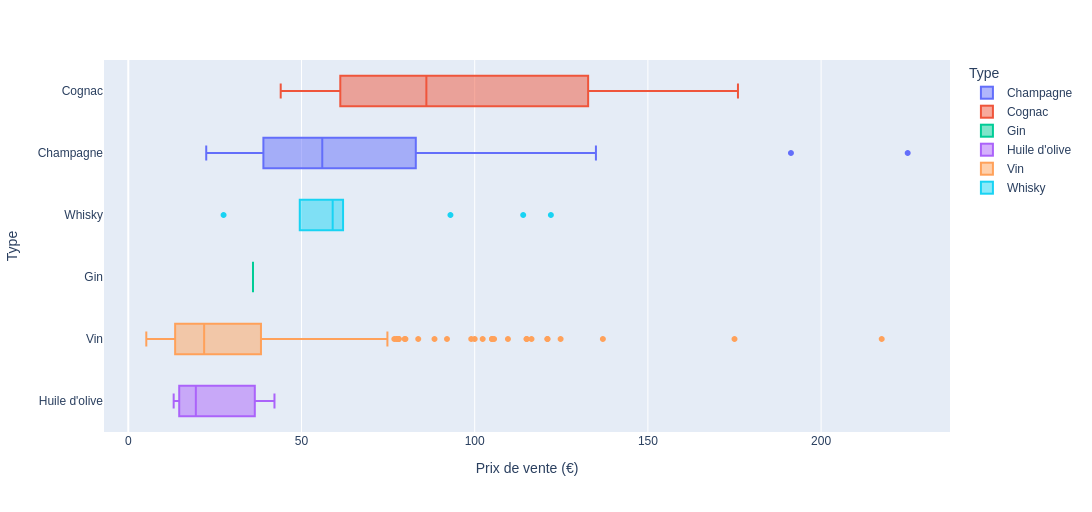

In [114]:
fig = px.box(
    df_clean, y="type", x="price", color="type", category_orders=category_orders, hover_data=df_clean,
    labels={"type":"Type","price":"Prix de vente (€)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="mean ascending")
fig.show()

In [115]:
test_quanti_multi(df_clean, quanti="price", multi="type")

ℹ️ [Shapiro-Wilk] 1/6 groupes suivent une distribution normale.
✅ [Kruskal-Wallis] Différence significative entre les groupes
🌗 [ε² = 0.116] Effet modéré


/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Huile d'olive has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")
/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Gin has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")


La différence entre catégories est significative.
Certaines catégories sont plutôt proches (chevauchement des boîtes à moustaches), d'autres éloignées (non-chevauchement de la partie boîte sans la moustache), d'où un effet global assez fort.

# Autres analyses univariées 

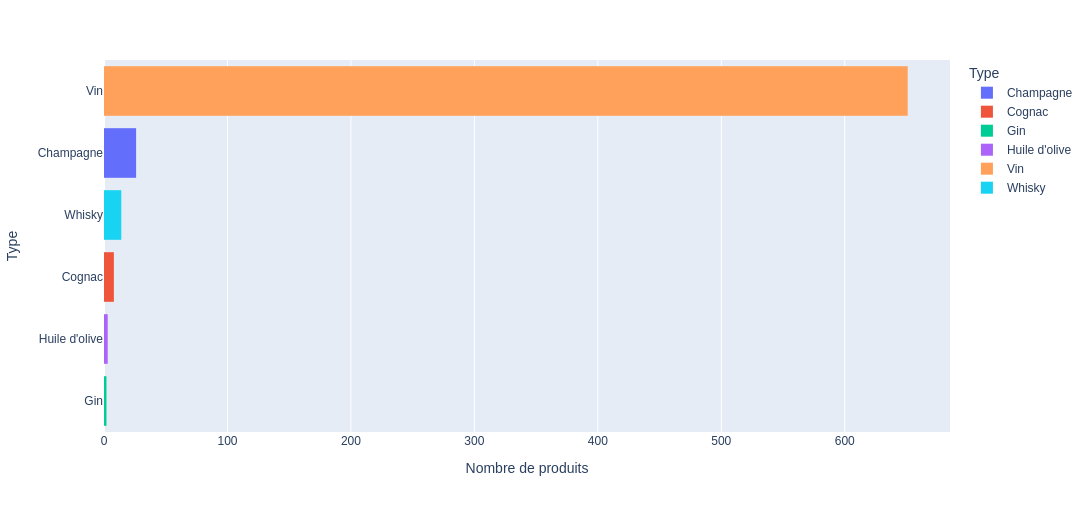

In [116]:
fig = px.histogram(
    df_clean, y="type", color="type", category_orders=category_orders,
    labels={"type":"Type"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.update_layout(xaxis_title="Nombre de produits")
fig.show()

**Attention** : la catégorie des vins est largement sur-représentée, tandis que d'autres sont sous-représentées.
Cela peut impacte les tests statistiques (cf. `UserWarning`s).

## Analyse des ventes en CA

In [117]:
df_clean["CA"] = df_clean["price"] * df_clean["total_sales"]
df_clean.sort_values(by="CA", ascending=False, inplace=True, ignore_index=True)
df_clean

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA
0,4352,225.0,0,137.81,15940,Champagne,Champagne Egly-Ouriet Grand Cru Millésimé 2008,champagne-egly-ouriet-grand-cru-millesime-2008,11,2475.0
1,5892,191.3,98,116.06,14983,Champagne,Coteaux Champenois Egly-Ouriet Ambonnay Rouge ...,coteaux-champenois-egly-ouriet-ambonnay-rouge-...,6,1147.8
2,4353,79.5,127,45.91,12587,Champagne,Champagne Egly-Ouriet Grand Cru Brut Rosé,champagne-egly-ouriet-grand-cru-brut-rose,14,1113.0
3,5826,41.2,34,21.71,15325,Vin,Agnès Levet Côte Rôtie Améthyste 2017,agnes-levet-amethyste-2017,20,824.0
4,6212,115.0,16,59.42,13996,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,domaine-des-comtes-lafon-volnay-1er-cru-santen...,7,805.0
...,...,...,...,...,...,...,...,...,...,...
699,4079,37.0,0,19.50,13078,Vin,Le Vieux Donjon Châteauneuf-du-Pape 2013,vieux-donjon-chateauneuf-2013,0,0.0
700,4065,19.5,0,9.67,15022,Vin,Oratoire Saint Martin Cairanne Rouge Les Douye...,oratoire-saint-martin-cairanne-douyes-2016,0,0.0
701,5707,10.8,0,5.69,13557,Vin,Domaine des Terres d'Ocre Saint-Pourçain Rouge...,domaine-des-terres-docre-saint-pourcain-rouge-...,0,0.0
702,4052,33.7,0,18.11,16030,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Blanc ...,mont-olivet-chateauneuf-pape-blanc-2019,0,0.0


In [118]:
ca_total = df_clean["CA"].sum()
print(f"Chiffre d'affaires total = {ca_total:_.2f}€")

Chiffre d'affaires total = 141_867.60€


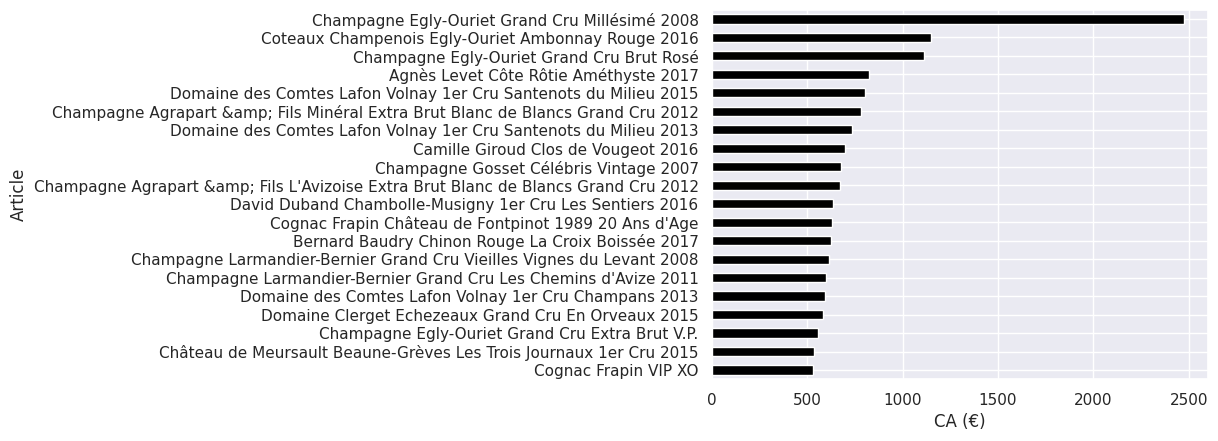

In [119]:
df_clean[19::-1].plot.barh(x="title", y="CA", color="black", legend=False)
plt.ylabel("Article")
plt.xlabel("CA (€)")
plt.show()

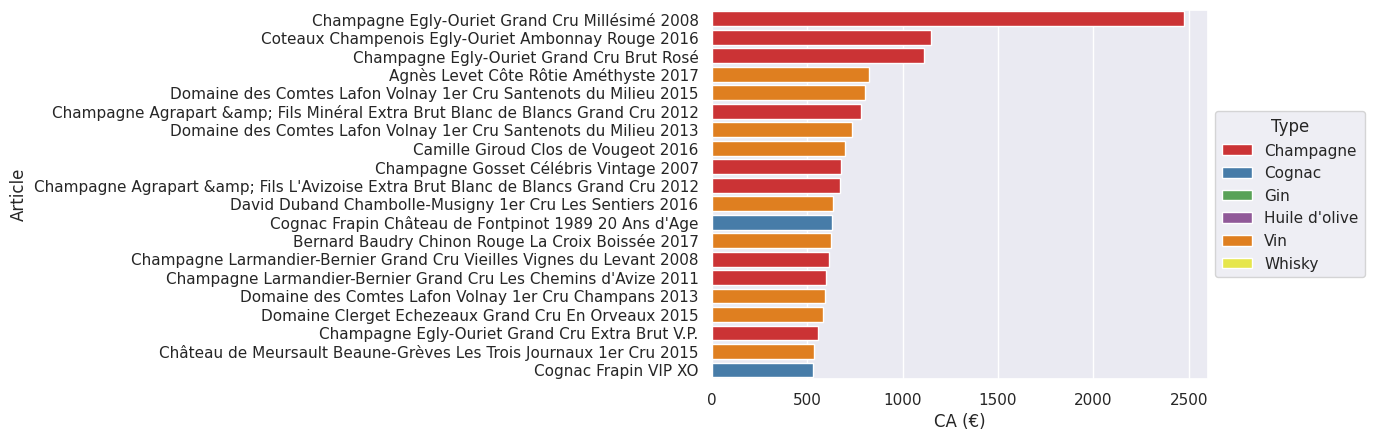

In [120]:
sns.barplot(df_clean[:20], y="title", x="CA", hue="type", hue_order=hue_order)
plt.ylabel("Article")
plt.xlabel("CA (€)")
plt.legend(title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

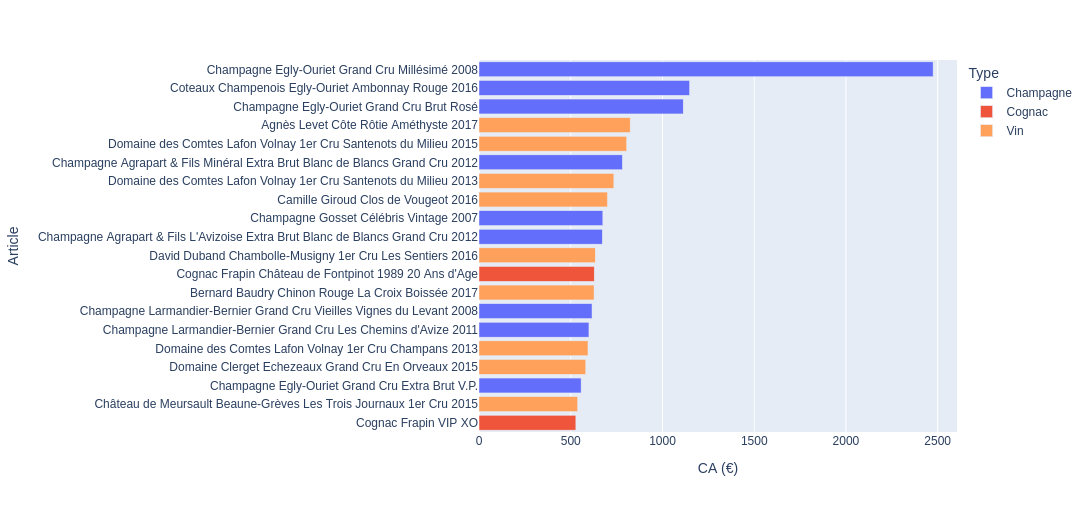

In [121]:
fig = px.bar(
    df_clean[:20], y="title", x="CA", color="type", category_orders=category_orders,
    labels={"title":"Article","CA":"CA (€)","type":"Type"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

Parmi les 20 produits qui rapportent le plus, on trouve principalement des Champagne et des vins, notamment de type Grand Cru ou 1er Cru.

In [122]:
lorenz_data = df_clean.loc[::-1,"CA"] # descending -> ascending
lorenz_data = 100. * lorenz_data / ca_total
lorenz_data = lorenz_data.cumsum()

In [123]:
num = (lorenz_data > 20).sum()
den = df_clean.shape[0]
print(f"Articles représentant 80% du CA : {num}/{den} = {100.*num/den:.2f}%")

Articles représentant 80% du CA : 429/704 = 60.94%


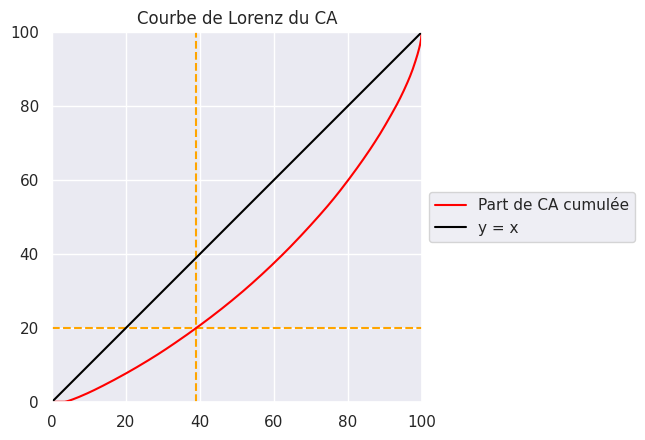

In [124]:
fix, ax = plt.subplots()
ax.set_aspect("equal", adjustable="box")
plt.plot([0,100], [20]*2, color="orange", linestyle="--")
plt.plot([(704-429)/704*100]*2, [0,100], color="orange", linestyle="--")
plt.plot(np.linspace(0,100,704), lorenz_data, color="red", label="Part de CA cumulée")
plt.plot([0,100], [0,100], color="black", label="y = x")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title("Courbe de Lorenz du CA")
plt.show()

In [125]:
print(f"Indice de Gini = {indice_gini(df_clean["CA"].values):.3f}")

Indice de Gini = 0.323


### Complément statistique

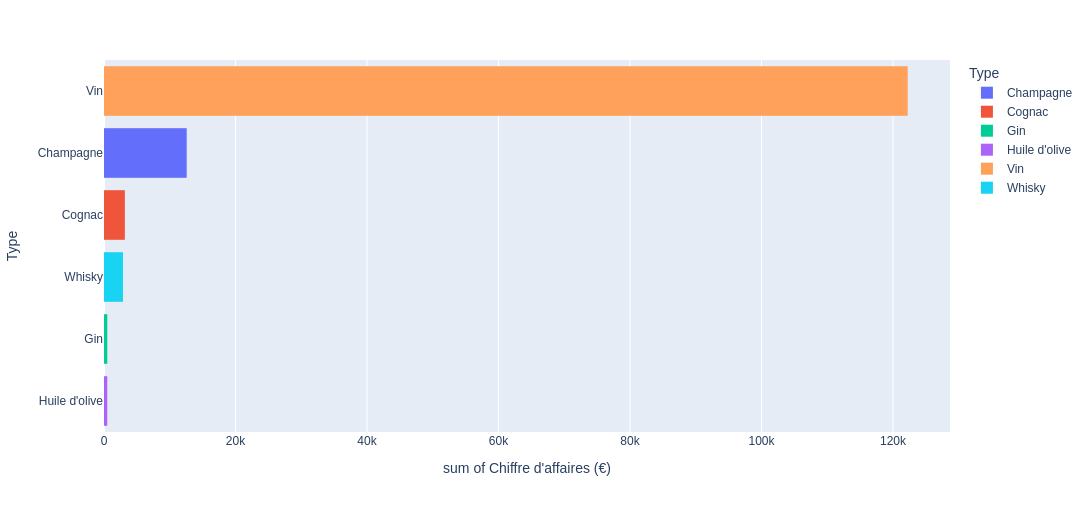

In [126]:
fig = px.histogram(
    df_clean, y="type", x="CA", color="type", category_orders=category_orders, histfunc="sum",
    labels={"type":"Type","CA":"Chiffre d'affaires (€)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

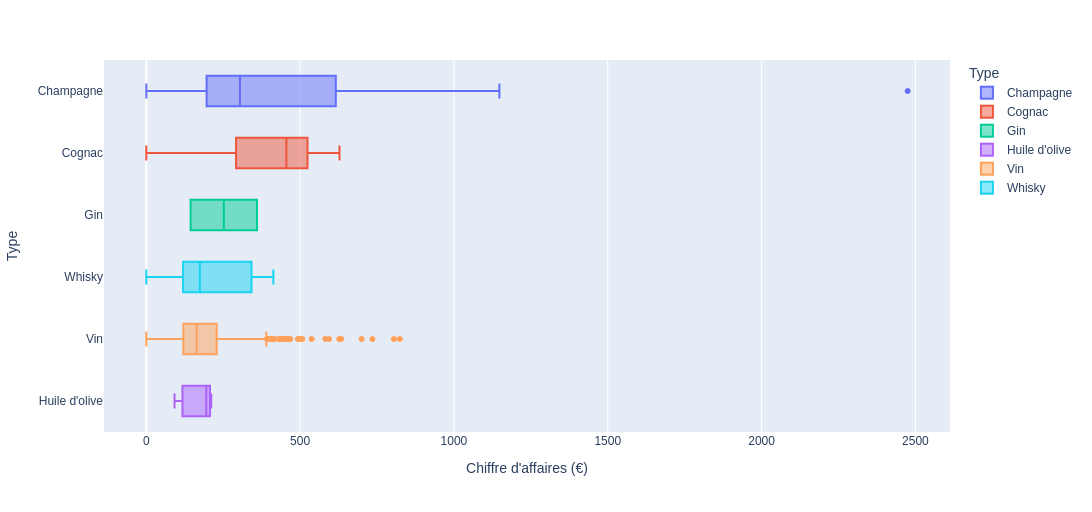

In [127]:
fig = px.box(
    df_clean, y="type", x="CA", color="type", category_orders=category_orders, hover_data=df_clean,
    labels={"type":"Type","CA":"Chiffre d'affaires (€)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="mean ascending")
fig.show()

In [128]:
test_quanti_multi(df_clean, quanti="CA", multi="type")

ℹ️ [Shapiro-Wilk] 2/6 groupes suivent une distribution normale.
✅ [Kruskal-Wallis] Différence significative entre les groupes
🌘 [ε² = 0.049] Effet faible


/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Gin has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")
/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Huile d'olive has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")


La catégorie des vins rapporte beaucoup plus, grâce à une contribution faible de très nombreux produits.

La différence entre catégories est significative, mais l'effet est faible.

## Analyse des ventes en quantité

In [129]:
df_clean.sort_values(by="total_sales", ascending=False, inplace=True, ignore_index=True)
df_clean

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA
0,4867,9.9,121,4.86,16148,Vin,Château De La Selve IGP Coteaux de l'Ardèche M...,chateau-de-la-selve-igp-coteaux-de-lardeche-ma...,36,356.4
1,4203,9.9,74,5.01,15415,Vin,Mas Laval IGP Pays d'Hérault Les Pampres Blanc...,mas-laval-igp-pays-herault-pampres-blanc-2018,27,267.3
2,4275,14.9,62,7.78,14864,Vin,I Fabbri Chianti Classico Lamole 2017,i-fabbri-chianti-classico-lamole-2017,24,357.6
3,4647,28.5,45,14.14,16525,Vin,Bernard Baudry Chinon Rouge La Croix Boissée 2017,bernard-baudry-chinon-rouge-croix-boissee-2017,22,627.0
4,6129,5.2,68,2.74,14570,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Bl...,moulin-de-gassac-igp-pays-dherault-guilhem-bla...,20,104.0
...,...,...,...,...,...,...,...,...,...,...
699,6038,48.5,0,25.31,15318,Vin,I Fabbri Chianti Classico Gran Selezione 2015,i-fabbri-chianti-classico-gran-selezione-2015,0,0.0
700,4198,5.8,0,2.97,16322,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,moulin-gassac-igp-pays-herault-guilhem-rouge-2019,0,0.0
701,4923,7.0,0,3.65,15928,Vin,Cave de Castelmaure Corbières Rouge Vigneron 2018,cave-de-castelmaure-corbieres-rouge-vigneron-2018,0,0.0
702,4396,62.0,0,28.42,9636,Whisky,Wemyss Malts Blended Malt Scotch Whisky The Hi...,whisky-wemyss-the-hive-12-ans,0,0.0


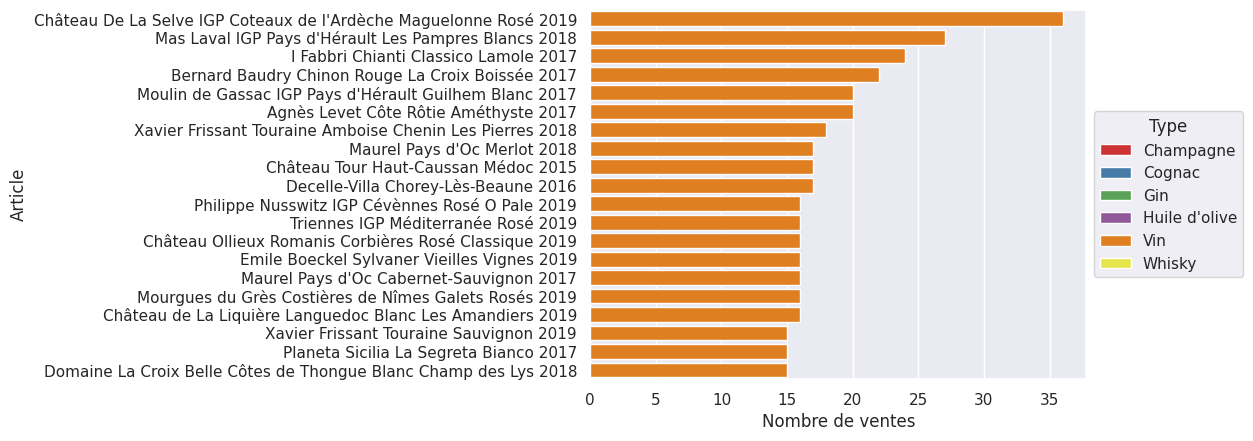

In [130]:
sns.barplot(df_clean[:20], y="title", x="total_sales", hue="type", hue_order=hue_order)
plt.ylabel("Article")
plt.xlabel("Nombre de ventes")
plt.legend(title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

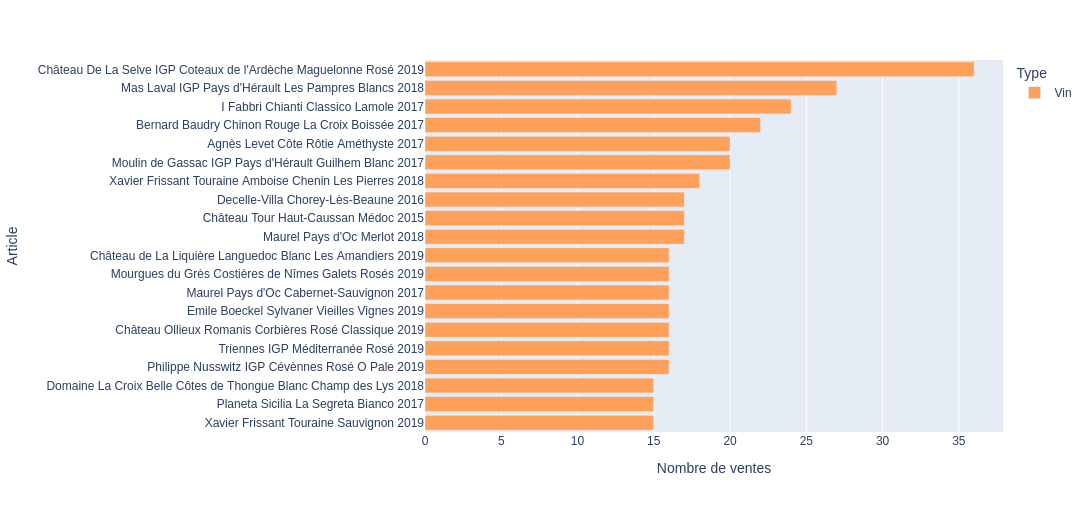

In [131]:
fig = px.bar(
    df_clean[:20], y="title", x="total_sales", color="type", category_orders=category_orders,
    labels={"title":"Article","total_sales":"Nombre de ventes","type":"Type"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

Les 20 produits les plus vendus sont tous des vins.

In [132]:
total_sales_total = df_clean["total_sales"].sum()
print(f"Nombre total de ventes = {total_sales_total}")

Nombre total de ventes = 5668


In [133]:
lorenz_data = df_clean.loc[::-1,"total_sales"] # descending -> ascending
lorenz_data = 100. * lorenz_data / total_sales_total
lorenz_data = lorenz_data.cumsum()

In [134]:
num = (lorenz_data > 20).sum()
den = df_clean.shape[0]
print(f"Articles représentant 80% des ventes en quantité : {num}/{den} = {100.*num/den:.2f}%")

Articles représentant 80% des ventes en quantité : 428/704 = 60.80%


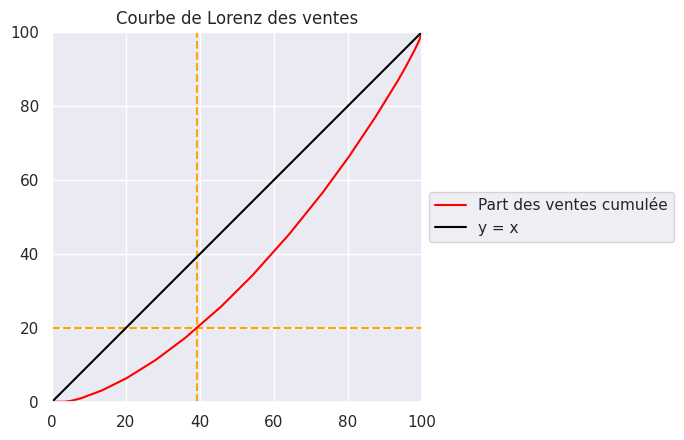

In [135]:
fix, ax = plt.subplots()
ax.set_aspect("equal", adjustable="box")
plt.plot([0,100], [20]*2, color="orange", linestyle="--")
plt.plot([(704-428)/704*100]*2, [0,100], color="orange", linestyle="--")
plt.plot(np.linspace(0,100,704), lorenz_data, color="red", label="Part des ventes cumulée")
plt.plot([0,100], [0,100], color="black", label="y = x")
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.title("Courbe de Lorenz des ventes")
plt.show()

In [136]:
print(f"Indice de Gini = {indice_gini(df_clean["total_sales"].values):.3f}")

Indice de Gini = 0.282


### Complément statistique

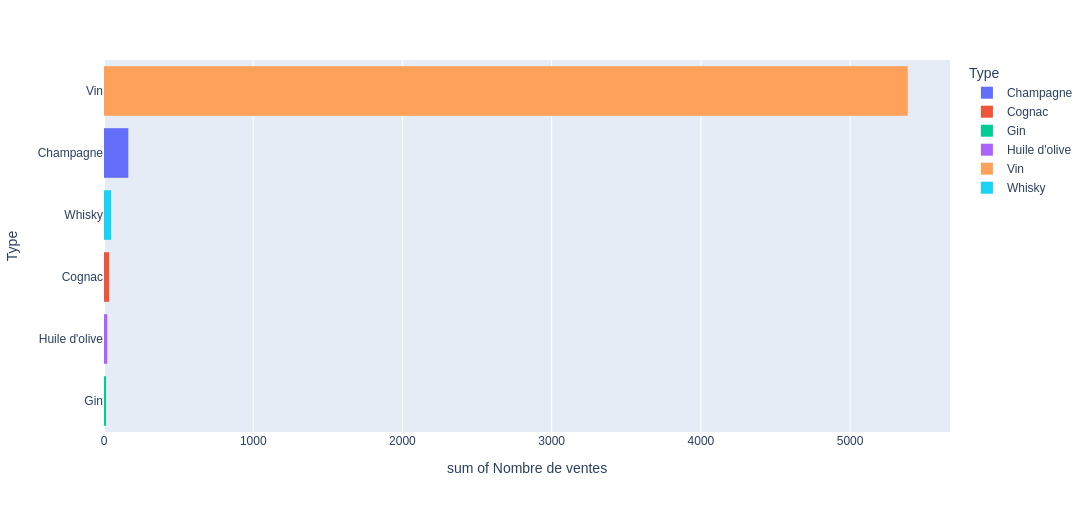

In [137]:
fig = px.histogram(
    df_clean, y="type", x="total_sales", color="type", category_orders=category_orders, histfunc="sum",
    labels={"type":"Type","total_sales":"Nombre de ventes"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

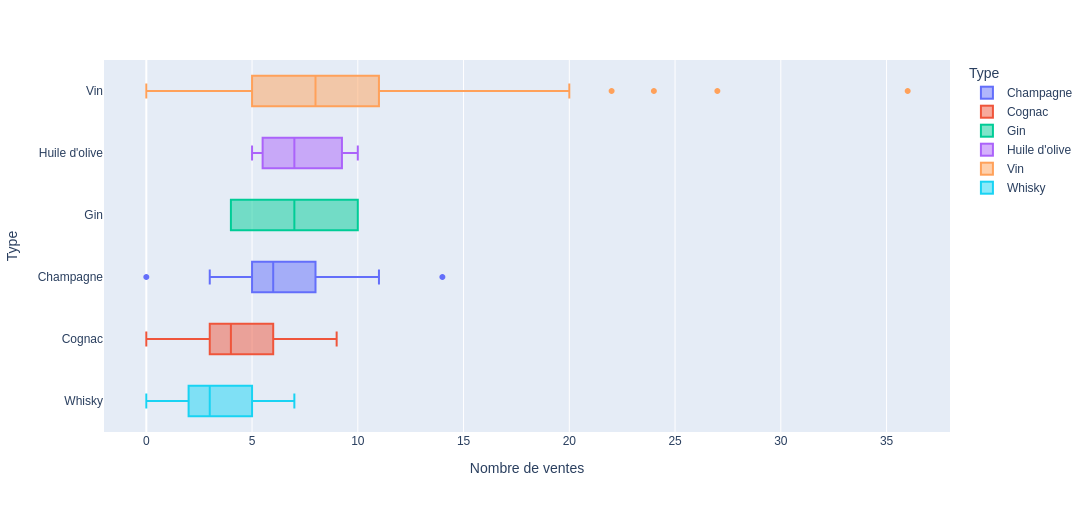

In [138]:
fig = px.box(
    df_clean, y="type", x="total_sales", color="type", category_orders=category_orders, hover_data=df_clean,
    labels={"type":"Type","total_sales":"Nombre de ventes"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="mean ascending")
fig.show()

In [139]:
test_quanti_multi(df_clean, quanti="total_sales", multi="type")

ℹ️ [Shapiro-Wilk] 3/6 groupes suivent une distribution normale.
✅ [Kruskal-Wallis] Différence significative entre les groupes
🌘 [ε² = 0.051] Effet faible


/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Huile d'olive has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")
/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Gin has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")


Beaucoup plus de vins sont vendus en raison de leur sur-représentation dans le catalogue global.
En revanche, le nombre d'unités vendues par article est en général légèrement (et non fortement) supérieur par rapport aux autre catégories.
C'est pouquoi la différence entre catégories est significative, mais l'effet est faible.

## Analyse des stocks

Les données portent sur le mois d'octobre.
Il est donc possible de calculer le nombre de mois de stock en divisant `stock_quantity` par `total_sales`.

In [140]:
df_clean["nb_months_stock"] = df_clean["stock_quantity"] / df_clean["total_sales"]
df_clean.sort_values(by="nb_months_stock", ascending=False, inplace=True, ignore_index=True)
df_clean

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock
0,4337,83.0,145,48.90,4679,Champagne,Champagne Mailly Grand Cru Les Echansons 2007,champagne-mailly-grand-cru-les-echansons-2007,0,0.0,inf
1,5932,59.9,13,27.18,523,Cognac,Cognac Normandin Mercier VFC,cognac-normandin-mercier-vfc,0,0.0,inf
2,4142,53.0,125,32.15,11641,Champagne,Champagne Gosset Grand Millésime 2006,champagne-gosset-grand-millesime-2006,4,212.0,31.25
3,6126,135.0,138,80.33,14923,Champagne,Champagne Gosset Célébris Vintage 2007,champagne-gosset-celebris-vintage-2007,5,675.0,27.60
4,4356,51.6,81,31.00,12585,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,champagne-egly-ouriet-premier-cru-vrigny,3,154.8,27.00
...,...,...,...,...,...,...,...,...,...,...,...
699,6038,48.5,0,25.31,15318,Vin,I Fabbri Chianti Classico Gran Selezione 2015,i-fabbri-chianti-classico-gran-selezione-2015,0,0.0,NaN
700,4198,5.8,0,2.97,16322,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,moulin-gassac-igp-pays-herault-guilhem-rouge-2019,0,0.0,NaN
701,4923,7.0,0,3.65,15928,Vin,Cave de Castelmaure Corbières Rouge Vigneron 2018,cave-de-castelmaure-corbieres-rouge-vigneron-2018,0,0.0,NaN
702,4396,62.0,0,28.42,9636,Whisky,Wemyss Malts Blended Malt Scotch Whisky The Hi...,whisky-wemyss-the-hive-12-ans,0,0.0,NaN


Le nombre de mois de stock est indéfini (NaN) lorsque `stock_quantity` = `total_sales` = 0.

Cela correspond à **22** produits en rupture de stock et sans vente.
Attention : est-ce normal qu'ils apparaissent sur le site web ?

Nous retirons les lignes correspondantes dans la suite de cette analyse (nouveau DataFrame).

In [141]:
print(f"Le nombre de mois de stock est indéfini (NaN) dans {df_clean["nb_months_stock"].isna().sum()} lignes.")

Le nombre de mois de stock est indéfini (NaN) dans 22 lignes.


In [142]:
df_clean[ df_clean["nb_months_stock"].isna() ]

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock
682,4606,50.1,0,24.59,15149,Vin,Catherine et Claude Maréchal Volnay 2017,catherine-et-claude-marechal-volnay-2017,0,0.0,NaN
683,5384,28.8,0,15.18,14149,Vin,Liban Vallée de la Békaa Château Marsyas 2012,liban-vallee-de-la-bekaa-chateau-marsyas-2012,0,0.0,NaN
684,4876,22.8,0,11.90,16289,Vin,Tempier Bandol Rosé 2019,tempier-bandol-rose-2019,0,0.0,NaN
685,4065,19.5,0,9.67,15022,Vin,Oratoire Saint Martin Cairanne Rouge Les Douye...,oratoire-saint-martin-cairanne-douyes-2016,0,0.0,NaN
686,5712,57.6,0,30.36,14241,Vin,Albert Mann Gewurztraminer Vendanges Tardives ...,albert-mann-gewurztraminer-vendanges-tardives-...,0,0.0,NaN
687,4079,37.0,0,19.50,13078,Vin,Le Vieux Donjon Châteauneuf-du-Pape 2013,vieux-donjon-chateauneuf-2013,0,0.0,NaN
688,4100,15.8,0,8.57,13416,Vin,Emile Boeckel Gewurztraminer Grand Cru Zotzenb...,boeckel-gewurzt-gc-zotzenberg-2016,0,0.0,NaN
689,5707,10.8,0,5.69,13557,Vin,Domaine des Terres d'Ocre Saint-Pourçain Rouge...,domaine-des-terres-docre-saint-pourcain-rouge-...,0,0.0,NaN
690,4051,7.7,0,4.14,16045,Vin,Jeanne Gaillard IGP Collines Rhodaniennes Syra...,pierre-gaillard-syrah-terre-mandrin-2018,0,0.0,NaN
691,4052,33.7,0,18.11,16030,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape Blanc ...,mont-olivet-chateauneuf-pape-blanc-2019,0,0.0,NaN


In [143]:
df_stock_rotation = df_clean[ df_clean["nb_months_stock"].notna() ]
df_stock_rotation.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       682 non-null    int64  
 1   price            682 non-null    float64
 2   stock_quantity   682 non-null    int64  
 3   purchase_price   682 non-null    float64
 4   sku              682 non-null    str    
 5   type             682 non-null    str    
 6   title            682 non-null    str    
 7   name             682 non-null    str    
 8   total_sales      682 non-null    int64  
 9   CA               682 non-null    float64
 10  nb_months_stock  682 non-null    float64
dtypes: float64(4), int64(3), str(4)
memory usage: 125.4 KB


Le nombre de mois de stock est infini lorsque `stock_quantity` > 0 et `total_sales` = 0.

Cela correspond à **2** produits en stock et sans vente. Attention : pourquoi personne n'achète ces produits ?

Nous retirons les lignes correspondantes dans la suite de cette analyse.

In [144]:
print(f"Le nombre de mois de stock est infini dans {(~np.isfinite(df_stock_rotation["nb_months_stock"])).sum()} lignes.")

Le nombre de mois de stock est infini dans 2 lignes.


In [145]:
df_stock_rotation[ ~np.isfinite(df_stock_rotation["nb_months_stock"]) ]

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock
0,4337,83.0,145,48.90,4679,Champagne,Champagne Mailly Grand Cru Les Echansons 2007,champagne-mailly-grand-cru-les-echansons-2007,0,0.0,inf
1,5932,59.9,13,27.18,523,Cognac,Cognac Normandin Mercier VFC,cognac-normandin-mercier-vfc,0,0.0,inf


In [146]:
df_stock_rotation = df_stock_rotation[ np.isfinite(df_stock_rotation["nb_months_stock"]) ]
df_stock_rotation.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 680 entries, 2 to 681
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   product_id       680 non-null    int64  
 1   price            680 non-null    float64
 2   stock_quantity   680 non-null    int64  
 3   purchase_price   680 non-null    float64
 4   sku              680 non-null    str    
 5   type             680 non-null    str    
 6   title            680 non-null    str    
 7   name             680 non-null    str    
 8   total_sales      680 non-null    int64  
 9   CA               680 non-null    float64
 10  nb_months_stock  680 non-null    float64
dtypes: float64(4), int64(3), str(4)
memory usage: 125.1 KB


Le nombre de mois de stock est nul lorsque `stock_quantity` = 0 et `total_sales` > 0.

Cela correspond à **20** produits vendus en rupture de stock. Attention : faut-il prévoir un réapprovisionnement ?

In [147]:
print(f"Le nombre de mois de stock est nul dans {(df_stock_rotation["nb_months_stock"] == 0).sum()} lignes.")

Le nombre de mois de stock est nul dans 20 lignes.


In [148]:
df_stock_rotation[ (df_stock_rotation["nb_months_stock"] == 0) ]

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock
662,4241,8.90,0,4.37,14725,Vin,Parcé Frères IGP Côtes Catalanes Hommage à Fer...,parce-freres-hommage-fernand-blanc-2019,15,133.50,0.0
663,6050,38.50,0,20.09,15134,Vin,Christophe Pichon Condrieu 2017,christophe-pichon-saint-condrieu-2017,6,231.00,0.0
664,4179,24.00,0,13.02,16166,Vin,Domaine de l'Hortus Pic Saint-Loup La Grande C...,hortus-pic-saint-loup-grande-cuvee-2018,6,144.00,0.0
665,5565,92.00,0,46.11,19822,Vin,Tempier Bandol Cabassaou 2017,tempier-bandol-cabassaou-2017,1,92.00,0.0
666,4976,16.45,0,8.07,16005,Vin,Château Lafont Menaut Pessac-Leognan Rouge 2017,chateau-lafont-menaut-pessac-leognan-rouge-2017,7,115.15,0.0
667,5709,31.70,0,16.54,15035,Vin,Philippe Alliet Chinon Rouge Coteau de Noiré 2016,alliet-chinon-rouge-noire-2016,5,158.50,0.0
668,4612,20.60,0,10.22,15038,Vin,Gilbert Picq Chablis Vieilles Vignes 2017,gilbert-picq-chablis-vieilles-vignes-2017,5,103.00,0.0
669,4283,27.00,0,13.25,16154,Vin,Château de Cazeneuve Pic Saint-Loup Le Roc Des...,chateau-de-cazeneuve-pic-saint-loup-roc-des-ma...,8,216.00,0.0
670,5617,27.80,0,14.65,14844,Vin,Albert Boxler Pinot Gris Réserve 2016,albert-boxler-pinot-gris-reserve-2016,9,250.20,0.0
671,4858,6.50,0,3.19,16342,Vin,Château Turcaud Bordeaux Rosé 2019,chateau-turcaud-rose-2019,5,32.50,0.0


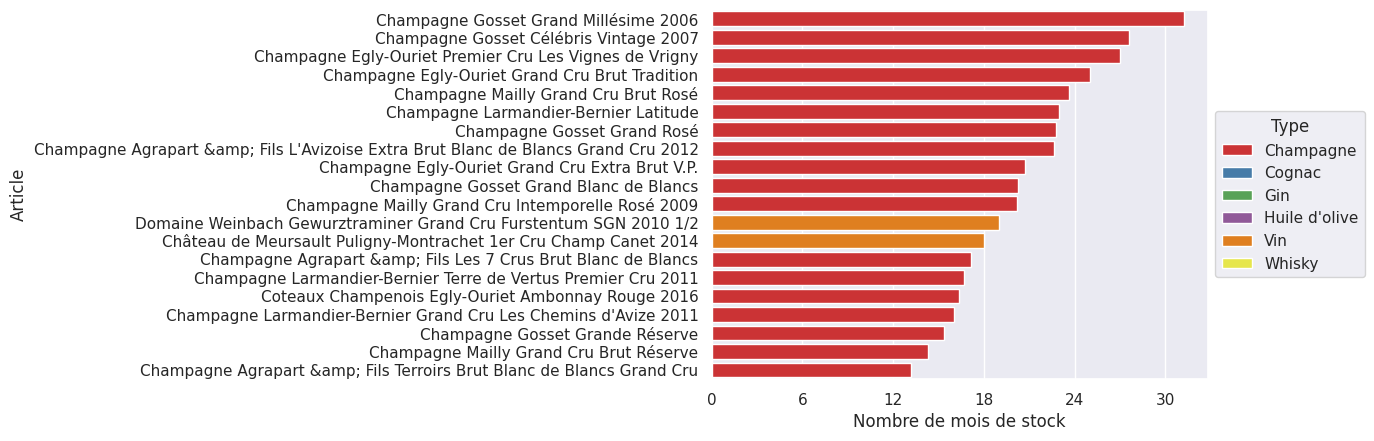

In [149]:
sns.barplot(df_stock_rotation[:20], y="title", x="nb_months_stock", hue="type", hue_order=hue_order)
plt.ylabel("Article")
plt.xlabel("Nombre de mois de stock")
plt.xticks(range(0,36,6))
plt.legend(title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

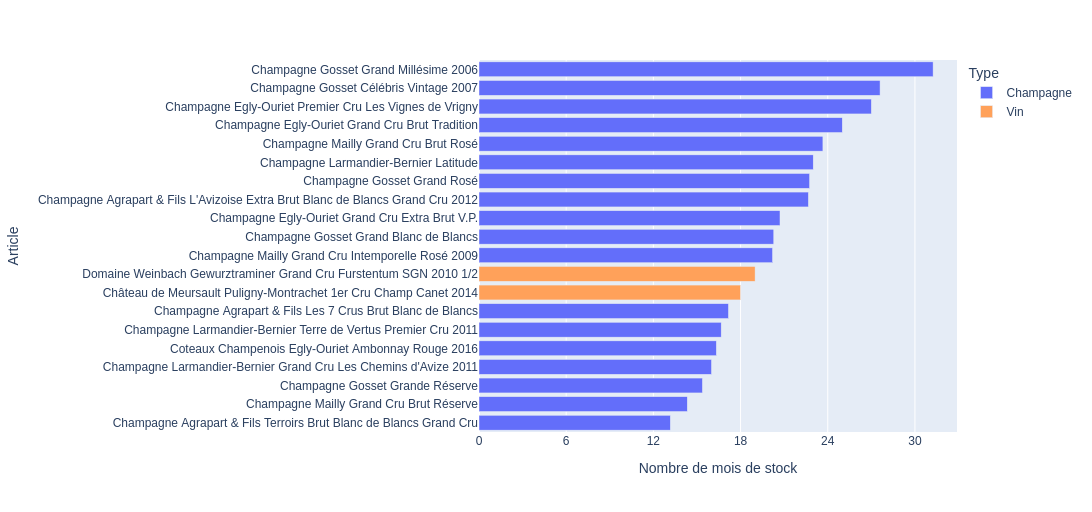

In [150]:
fig = px.bar(
    df_stock_rotation[:20], y="title", x="nb_months_stock", color="type", category_orders=category_orders,
    labels={"title":"Article","nb_months_stock":"Nombre de mois de stock","type":"Type"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending", xaxis={"dtick":6})
fig.show()

Le nombre de mois de stock semble très élevé (jusqu'à plus de 2 ans) avec des produits haut de gamme (e.g. Champagne, Grand Cru).

In [151]:
df_clean["stock_valorisation_euros"] = df_clean["purchase_price"] * df_clean["stock_quantity"]

In [152]:
stock_valorisation_euros_total = df_clean["stock_valorisation_euros"].sum()
print(f"Valorisation en € de l'ensemble du stock = {stock_valorisation_euros_total:_.2f}€")

Valorisation en € de l'ensemble du stock = 264_691.70€


In [153]:
stock_valorisation_count_total = df_clean["stock_quantity"].sum()
print(f"Nombre d'unités en stock = {stock_valorisation_count_total:_d}")

Nombre d'unités en stock = 16_425


*Rappel : les données portent sur le mois d'octobre.* Une anticipation de hausse des ventes pour les fêtes de fin d'année peut expliquer ce sur-stockage.

### Complément statistique

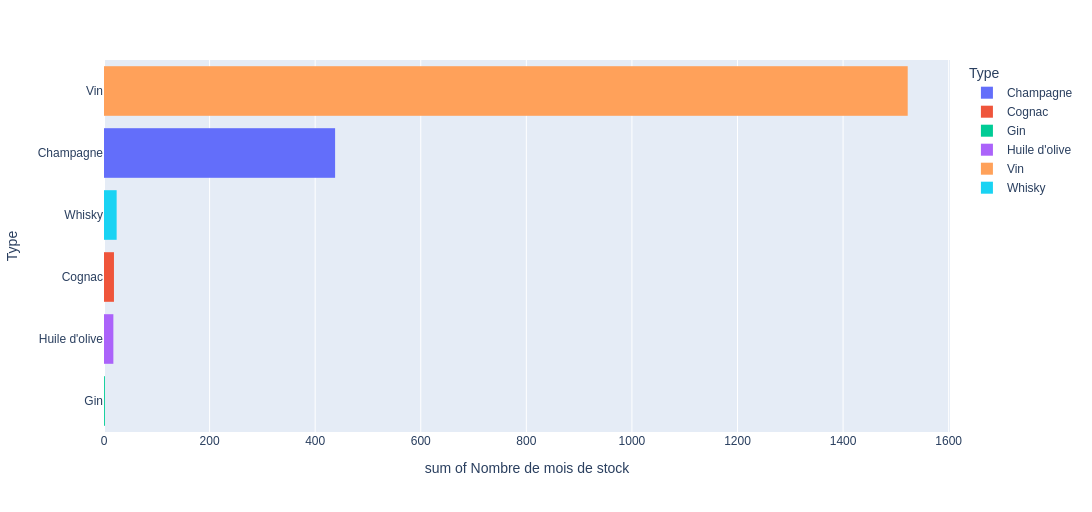

In [154]:
fig = px.histogram(
    df_clean, y="type", x="nb_months_stock", color="type", category_orders=category_orders, histfunc="sum",
    labels={"type":"Type","nb_months_stock":"Nombre de mois de stock"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

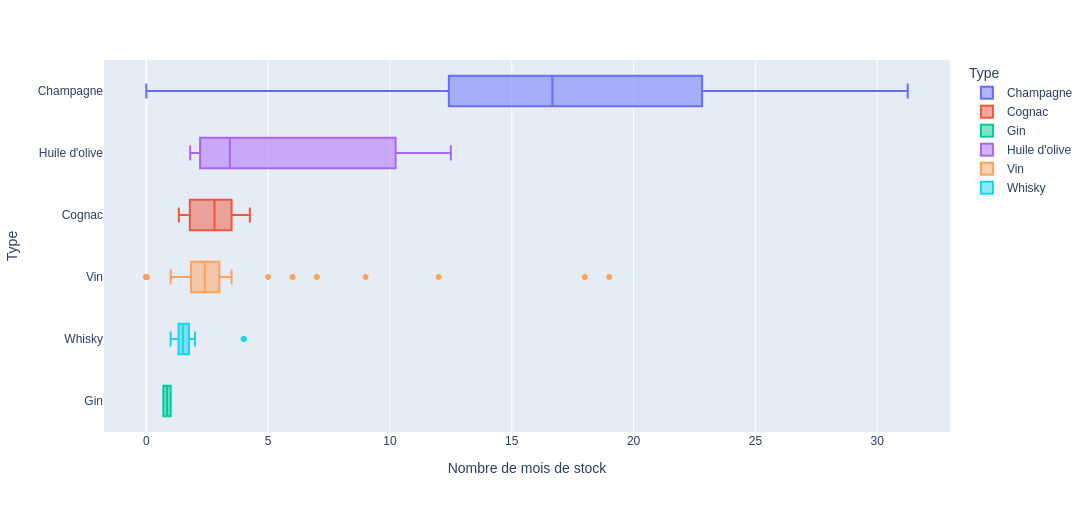

In [155]:
fig = px.box(
    df_clean, y="type", x="nb_months_stock", color="type", category_orders=category_orders, hover_data=df_clean,
    labels={"type":"Type","nb_months_stock":"Nombre de mois de stock"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="mean ascending")
fig.show()

In [156]:
test_quanti_multi(df_clean, quanti="nb_months_stock", multi="type")

ℹ️ [Shapiro-Wilk] 2/6 groupes suivent une distribution normale.
✅ [Kruskal-Wallis] Différence significative entre les groupes
🌗 [ε² = 0.111] Effet modéré


/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Huile d'olive has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")
/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Gin has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")


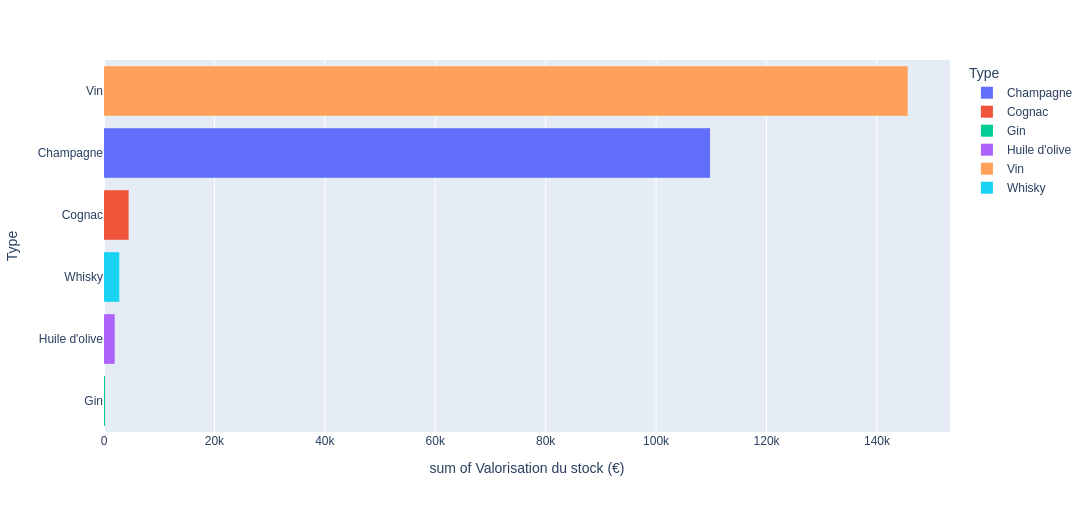

In [157]:
fig = px.histogram(
    df_clean, y="type", x="stock_valorisation_euros", color="type", category_orders=category_orders, histfunc="sum",
    labels={"type":"Type","stock_valorisation_euros":"Valorisation du stock (€)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

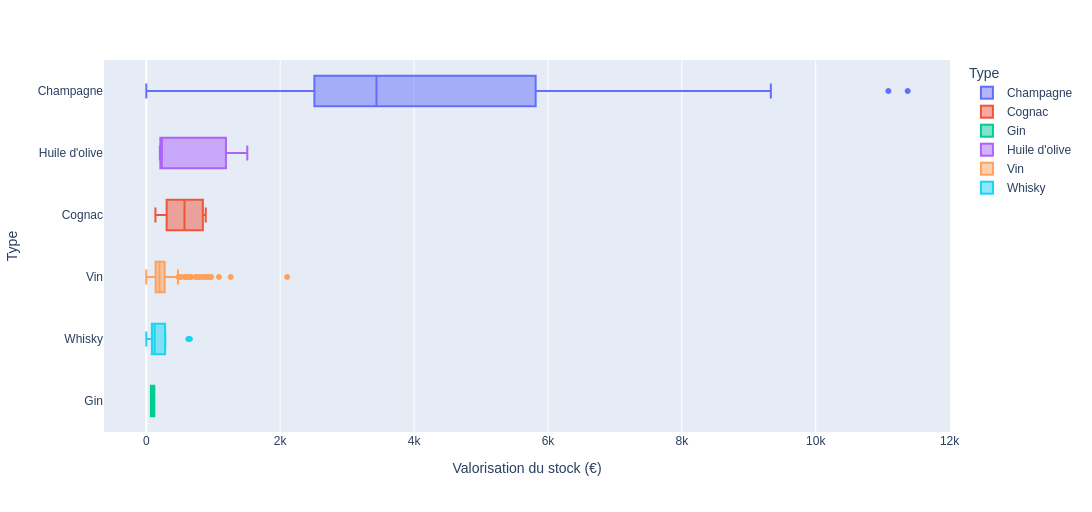

In [158]:
fig = px.box(
    df_clean, y="type", x="stock_valorisation_euros", color="type", category_orders=category_orders, hover_data=df_clean,
    labels={"type":"Type","stock_valorisation_euros":"Valorisation du stock (€)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="mean ascending")
fig.show()

In [159]:
test_quanti_multi(df_clean, quanti="stock_valorisation_euros", multi="type")

ℹ️ [Shapiro-Wilk] 1/6 groupes suivent une distribution normale.
✅ [Kruskal-Wallis] Différence significative entre les groupes
🌗 [ε² = 0.117] Effet modéré


/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Huile d'olive has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")
/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Gin has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")


Les produits de la catégorie Champagne sont sur-représentés dans le stock.
Cela est cohérent avec l'hypothèse d'anticipation des fêtes de fin d'année.

## Analyse de la marge

In [160]:
df_clean["marge"] = 100. * (df_clean["price"] - df_clean["purchase_price"]) / df_clean["purchase_price"]
df_clean

,product_id,price,stock_quantity,purchase_price,sku,type,title,name,total_sales,CA,nb_months_stock,stock_valorisation_euros,marge
0,4337,83.0,145,48.90,4679,Champagne,Champagne Mailly Grand Cru Les Echansons 2007,champagne-mailly-grand-cru-les-echansons-2007,0,0.0,inf,7090.50,69.734151
1,5932,59.9,13,27.18,523,Cognac,Cognac Normandin Mercier VFC,cognac-normandin-mercier-vfc,0,0.0,inf,353.34,120.382634
2,4142,53.0,125,32.15,11641,Champagne,Champagne Gosset Grand Millésime 2006,champagne-gosset-grand-millesime-2006,4,212.0,31.25,4018.75,64.852255
3,6126,135.0,138,80.33,14923,Champagne,Champagne Gosset Célébris Vintage 2007,champagne-gosset-celebris-vintage-2007,5,675.0,27.60,11085.54,68.056766
4,4356,51.6,81,31.00,12585,Champagne,Champagne Egly-Ouriet Premier Cru Les Vignes d...,champagne-egly-ouriet-premier-cru-vrigny,3,154.8,27.00,2511.00,66.451613
...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,6038,48.5,0,25.31,15318,Vin,I Fabbri Chianti Classico Gran Selezione 2015,i-fabbri-chianti-classico-gran-selezione-2015,0,0.0,NaN,0.00,91.623864
700,4198,5.8,0,2.97,16322,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,moulin-gassac-igp-pays-herault-guilhem-rouge-2019,0,0.0,NaN,0.00,95.286195
701,4923,7.0,0,3.65,15928,Vin,Cave de Castelmaure Corbières Rouge Vigneron 2018,cave-de-castelmaure-corbieres-rouge-vigneron-2018,0,0.0,NaN,0.00,91.780822
702,4396,62.0,0,28.42,9636,Whisky,Wemyss Malts Blended Malt Scotch Whisky The Hi...,whisky-wemyss-the-hive-12-ans,0,0.0,NaN,0.00,118.156228


In [161]:
df_clean["marge"].describe()

count    704.000000
mean      93.524039
std        9.456904
min       55.397390
25%       87.895212
50%       93.528757
75%       99.556541
max      129.694965
Name: marge, dtype: float64

In [162]:
df_marge_avg = df_clean[["type","marge"]].groupby("type").mean().sort_values(by="marge", ascending=False).reset_index()
df_marge_avg

,type,marge
0,Cognac,118.779435
1,Whisky,118.087005
2,Gin,109.790210
3,Vin,93.808889
4,Champagne,68.003774
5,Huile d'olive,60.068162


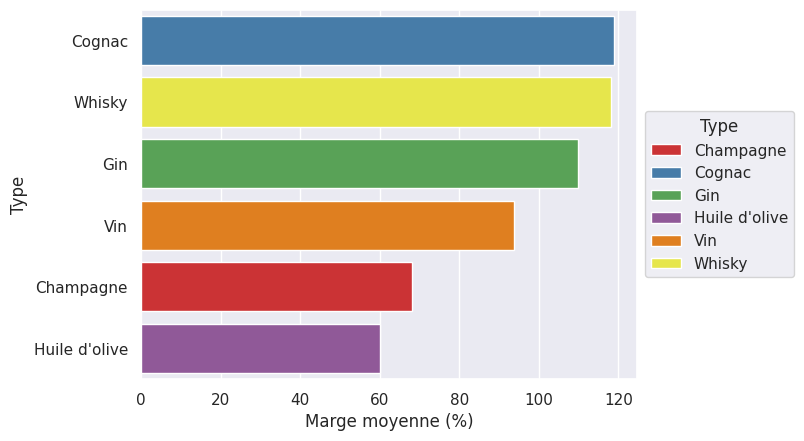

In [163]:
sns.barplot(df_marge_avg, y="type", x="marge", hue="type", hue_order=hue_order, legend=True)
plt.ylabel("Type")
plt.xlabel("Marge moyenne (%)")
plt.legend(title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

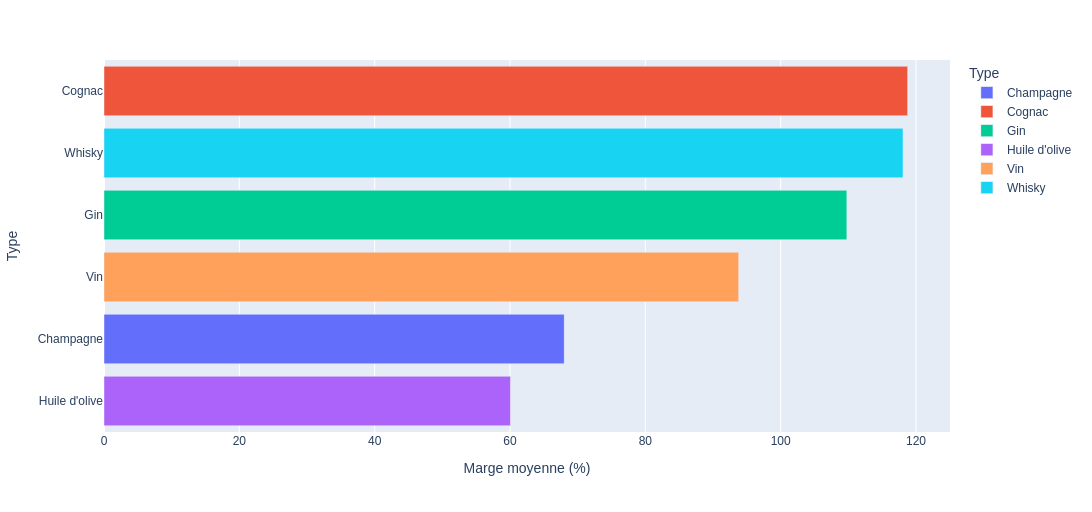

In [164]:
fig = px.bar(
    df_marge_avg, y="type", x="marge", color="type", category_orders=category_orders,
    labels={"type":"Type","marge":"Marge moyenne (%)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

La marge moyenne est élevée pour toutes les catégories (minimum 60% pour l'huile d'olive, maximum 120% pour le Cognac et le Whisky).

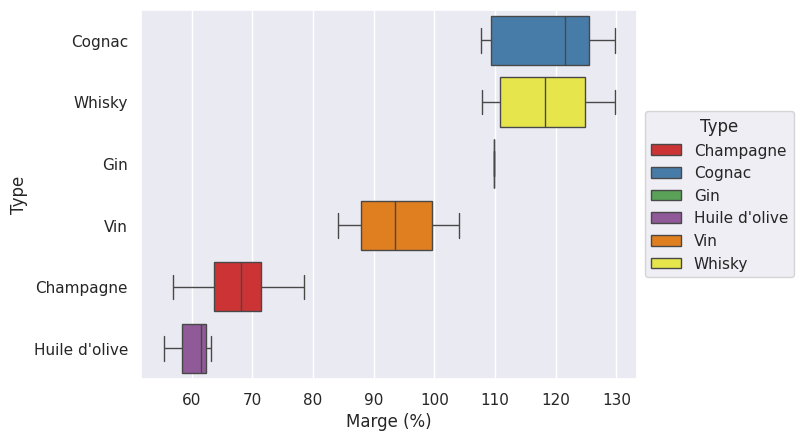

In [165]:
sns.boxplot(df_clean, y="type", x="marge", hue="type", hue_order=hue_order, order=df_marge_avg["type"])
plt.ylabel("Type")
plt.xlabel("Marge (%)")
plt.legend(hue_order, title="Type", loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

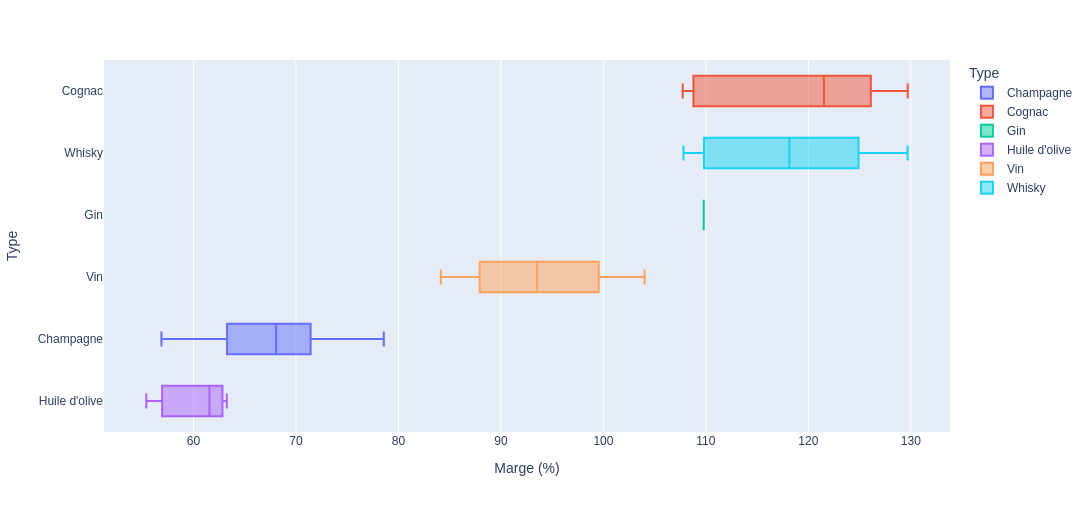

In [166]:
fig = px.box(
    df_clean, y="type", x="marge", color="type", category_orders=category_orders,
    labels={"type":"Type","marge":"Marge (%)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="mean ascending")
fig.show()

L'ordre selon la marge médiane est le même que l'ordre selon la marge moyenne.

### Complément statistique

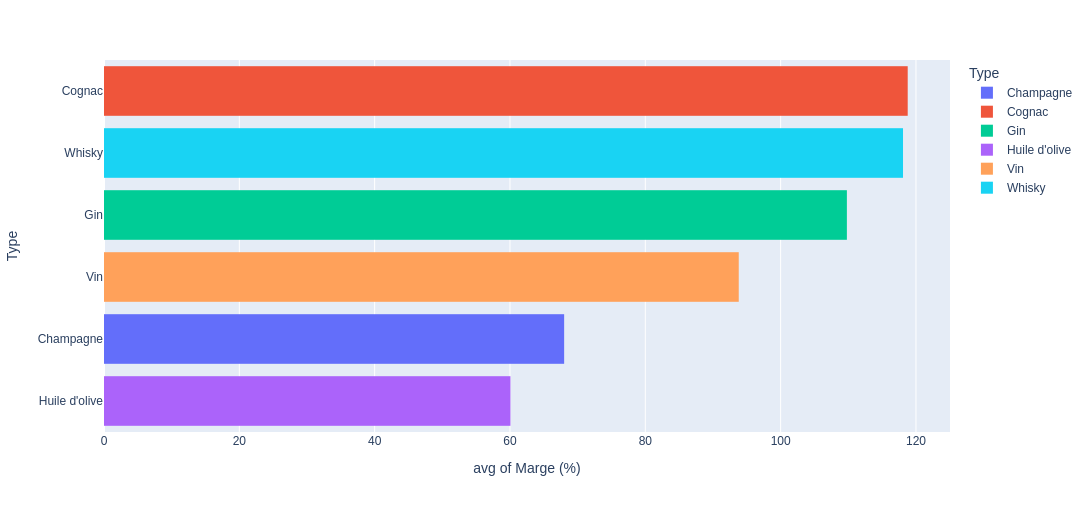

In [167]:
fig = px.histogram(
    df_clean, y="type", x="marge", color="type", category_orders=category_orders, histfunc="avg",
    labels={"type":"Type","marge":"Marge (%)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="total ascending")
fig.show()

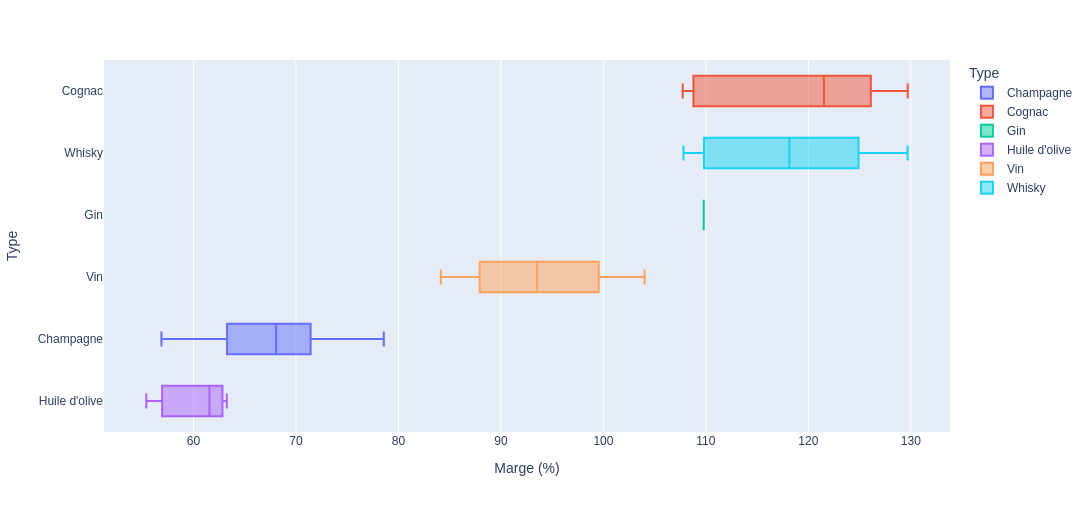

In [168]:
fig = px.box(
    df_clean, y="type", x="marge", color="type", category_orders=category_orders, hover_data=df_clean,
    labels={"type":"Type","marge":"Marge (%)"}, width=1100, height=500,
)
fig.update_layout(yaxis_categoryorder="mean ascending")
fig.show()

In [169]:
test_quanti_multi(df_clean, quanti="marge", multi="type")

ℹ️ [Shapiro-Wilk] 3/6 groupes suivent une distribution normale.
✅ [Kruskal-Wallis] Différence significative entre les groupes
🌖 [ε² = 0.209] Effet fort


/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Huile d'olive has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")
/home/user/Workspace/venv/lib/python3.12/site-packages/pingouin/distribution.py:243: UserWarning: Group Gin has less than 4 valid samples. Returning NaN.
  warnings.warn(f"Group {idx} has less than 4 valid samples. Returning NaN.")


Les tests statistiques permettent de confirmer mathématiquement ce que l'on observe dans les visualisations : la marge est très différente d'une catégorie à l'autre.

# Analyse des corrélations

In [170]:
df_corr = df_clean[["purchase_price","price","marge","total_sales","CA","stock_quantity","nb_months_stock"]].corr()
df_corr

,purchase_price,price,marge,total_sales,CA,stock_quantity,nb_months_stock
purchase_price,1.000000,0.992116,-0.127003,-0.497714,0.664794,-0.051347,0.260847
price,0.992116,1.000000,-0.031216,-0.518164,0.628353,-0.110841,0.209303
marge,-0.127003,-0.031216,1.000000,-0.034960,-0.190371,-0.444567,-0.461292
total_sales,-0.497714,-0.518164,-0.034960,1.000000,0.108711,0.471127,-0.065093
CA,0.664794,0.628353,-0.190371,0.108711,1.000000,0.173324,0.141457
stock_quantity,-0.051347,-0.110841,-0.444567,0.471127,0.173324,1.000000,0.776553
nb_months_stock,0.260847,0.209303,-0.461292,-0.065093,0.141457,0.776553,1.000000


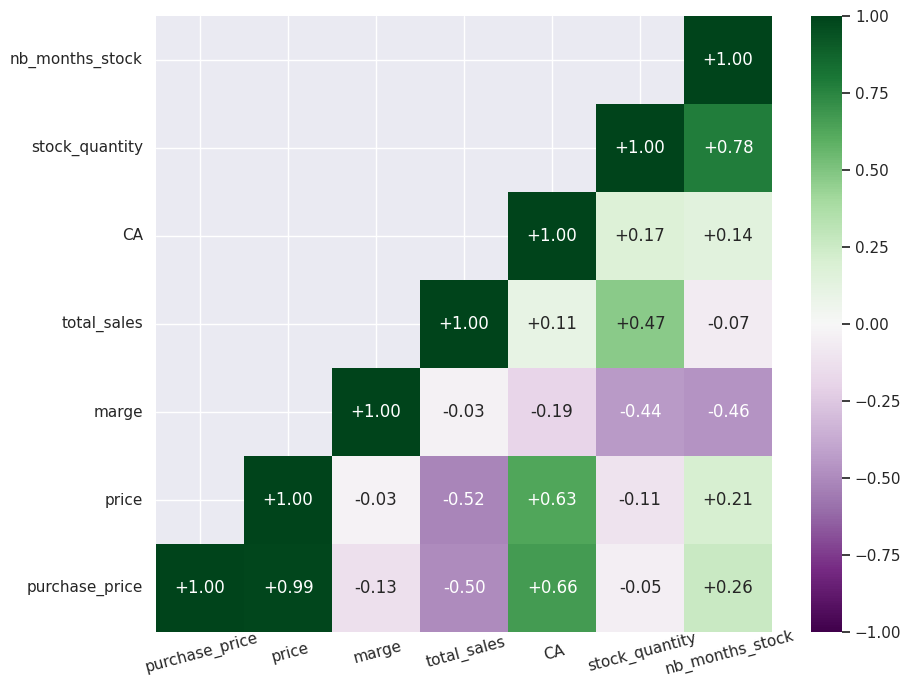

In [171]:
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(df_corr[::-1], annot=True, fmt="+.2f", vmin=-1, vmax=1, cmap="PRGn", square=True, mask=np.tri(*df_corr.shape,-1)[::-1], ax=ax)
plt.xticks(rotation=15, rotation_mode="anchor")
plt.show()

Analyse des corrélations positives
- +0.99 entre `price` et `purchase_price` (analyse approfondie ci-dessous, cf. 8.1)  
  Cette corrélation est très forte. Les corrélations de chacune de ces deux variables avec une autre variable sont très proches.  
  C'est pourquoi nous ne regardons désormais plus que `price`.
- +0.78 entre `nb_months_stock` et `stock_quantity`  
  Cela est dû à la relation : `nb_months_stock` = `stock_quantity` / `total_sales`  
  Cette corrélation est forte. Les corrélations de chacune de ces deux variables avec une autre variable (sauf `total_sales`) sont assez proches.  
  C'est pourquoi nous ne regardons désormais plus que `stock_quantity`.
- +0.63 entre `CA` et `price`  
  Cela est dû à la relation : `CA` = `price` × `total_sales`
- +0.47 entre `stock_quantity` et `total_sales`  
  Les niveaux de stock fin octobre correspondent à peu près aux volumes des ventes réalisées sur ce mois.

Analyse des corrélations négatives
- -0.52 entre `total_sales` et `price`  
  Un prix élevé a tendance à tirer les ventes à la baisse.
- -0.44 entre `marge` et `stock_quantity`  
  Le stock contient en majorité des produits dont la marge est plus petite.  
  Cela est cohérent avec le sur-stockage des Champagne (cf. 7.3) dont la marge est inférieure à celle des autres catégories (cf. 7.4).

## Analyse bivariée entre le prix de vente et le prix fournisseur

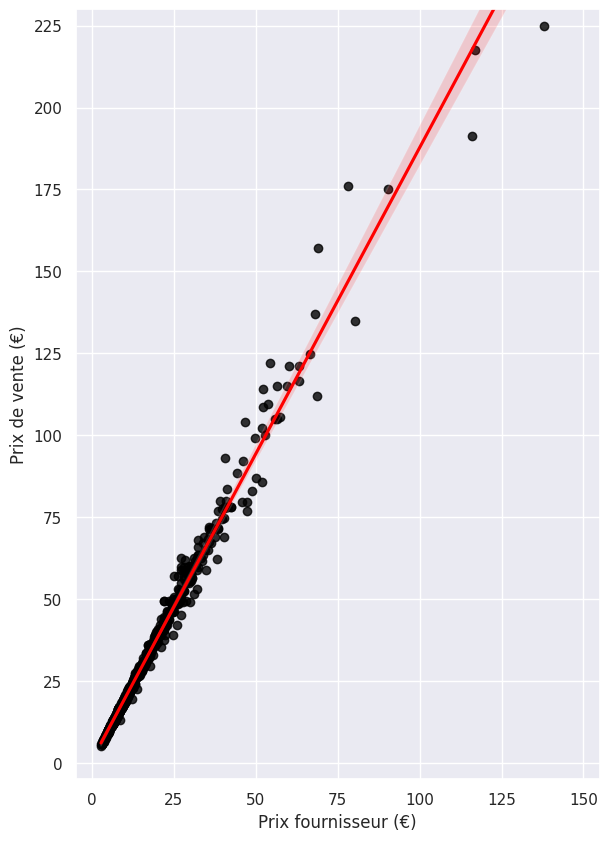

In [172]:
fig, ax = plt.subplots(figsize=(10,10))
ax.set_aspect("equal", adjustable="box")
sns.regplot(df_clean, y="price", x="purchase_price", color="black", line_kws={"color":"red"}, ax=ax)
plt.ylabel("Prix de vente (€)")
plt.xlabel("Prix fournisseur (€)")
plt.xticks(range(0,151,25))
plt.yticks(range(0,226,25))
plt.xlim(-5, 155)
plt.ylim(-5, 230)
plt.show()

In [173]:
result = scipy.stats.linregress(df_clean["purchase_price"], df_clean["price"])
a = result.slope
b = result.intercept
r = result.rvalue
print(f"Equation de droite : y={a:.3f}x{b:+.3f}")
print(f"Coefficient de corrélation (Pearson) : R = {r:+.3f}")
print(f"Coefficient de détermination : R² = {r*r:.3f}")

Equation de droite : y=1.868x+0.948
Coefficient de corrélation (Pearson) : R = +0.992
Coefficient de détermination : R² = 0.984


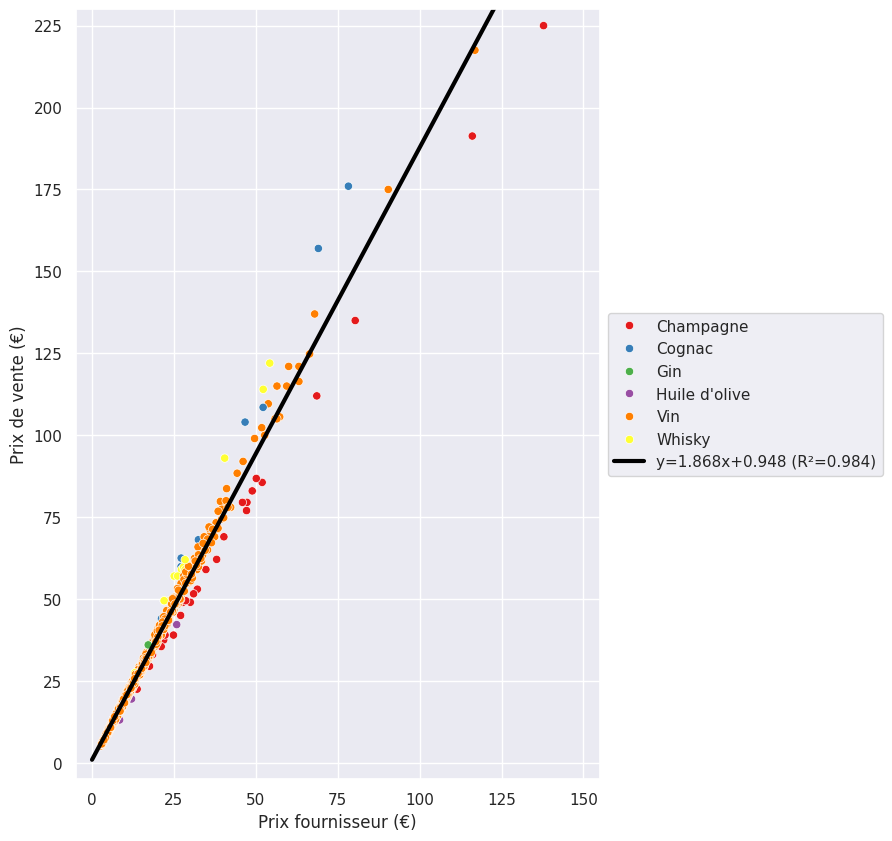

In [174]:
fig, ax = plt.subplots(figsize=(10,10))
ax.set_aspect("equal", adjustable="box")
sns.scatterplot(df_clean, y="price", x="purchase_price", hue="type", hue_order=hue_order, ax=ax)
plt.plot([0,150], [a*0+b,a*150+b], color="black", linewidth=3, label=f"y={a:.3f}x{b:+.3f} (R²={r*r:.3f})")
plt.ylabel("Prix de vente (€)")
plt.xlabel("Prix fournisseur (€)")
plt.xticks(range(0,151,25))
plt.yticks(range(0,226,25))
plt.xlim(-5, 155)
plt.ylim(-5, 230)
plt.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.show()

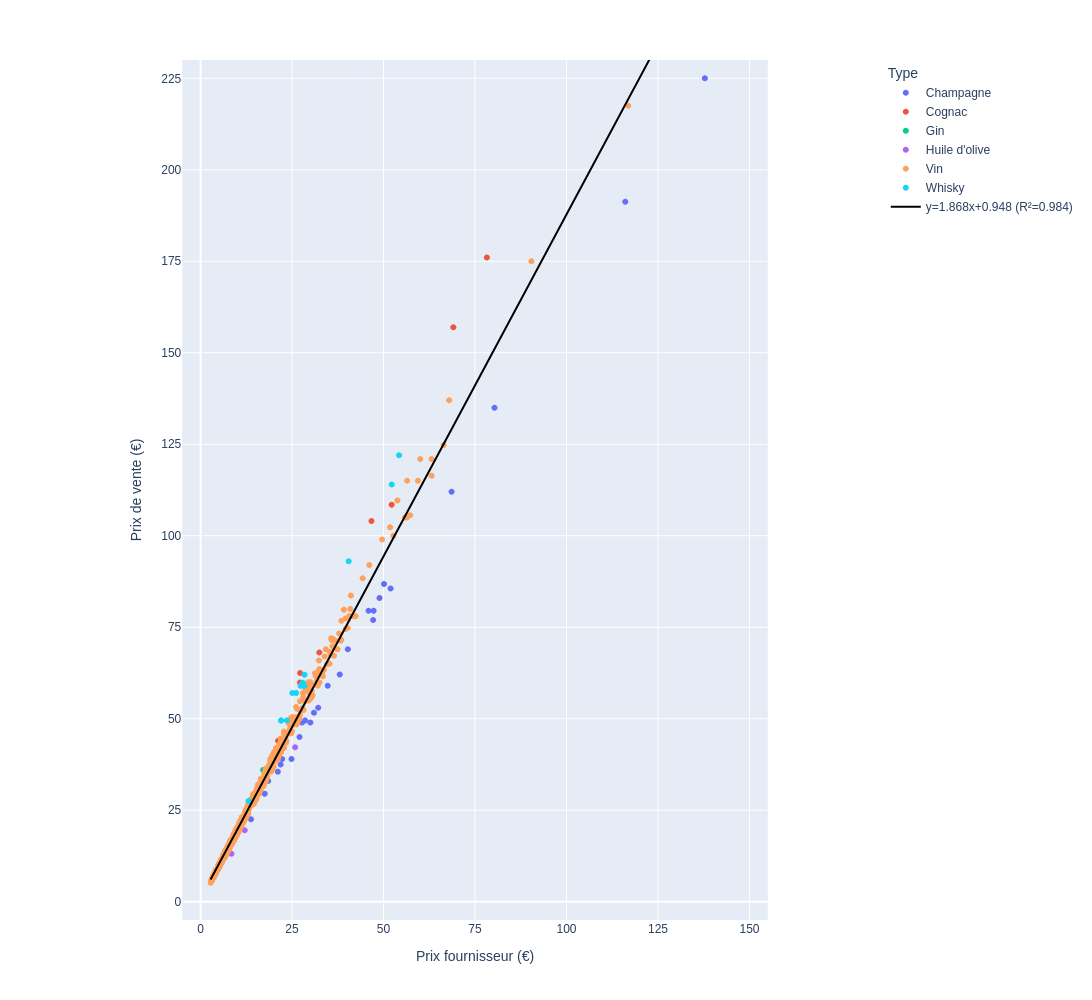

In [175]:
fig = px.scatter(
    df_clean, y="price", x="purchase_price", hover_name="title", color="type", category_orders=category_orders,
    labels={"type":"Type","purchase_price":"Prix fournisseur (€)","price":"Prix de vente (€)"},
    trendline="ols", trendline_scope="overall", trendline_color_override="black",
)
fig.for_each_trace(lambda trace: trace.update(name=trace.name.replace("Overall Trendline", f"y={a:.3f}x{b:+.3f} (R²={r*r:.3f})")))
fig.update_layout(
    width=900, height=1000,
    xaxis={"range":(-5,155),"dtick":25,"constrain":"domain"},
    yaxis={"range":(-5,230),"dtick":25,"constrain":"domain","scaleanchor":"x","scaleratio":1},
)
fig.show()

In [176]:
px.get_trendline_results(fig).iloc[0,0].summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                 4.399e+04
Date:                Thu, 27 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:29:17   Log-Likelihood:                -1874.4
No. Observations:                 704   AIC:                             3753.
Df Residuals:                     702   BIC:                             3762.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9478      0.199      4.764      0.000       0.557       1.338
x1             1.8684      0.009    209.743      0.000       1.851       1.886
==============================================================================
Omnibus:                      227.744   Durbin-Watson:                   1.879
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            31674.011
Skew:                          -0.068   Prob(JB):                         0.00
Kurtosis:                      35.860   Cond. No.                         34.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Complément statistique

In [177]:
pg.linear_regression(df_clean["purchase_price"], df_clean["price"])

,names,coef,se,T,pval,r2,adj_r2,CI2.5,CI97.5
0,Intercept,0.947756,0.198946,4.763881,0.000002,0.984293,0.984271,0.557155,1.338357
1,purchase_price,1.868407,0.008908,209.743260,0.000000,0.984293,0.984271,1.850918,1.885897


In [178]:
test_quanti_quanti(df_clean, x="purchase_price", y="price")

ℹ️ [Shapiro-Wilk] La variable x=purchase_price ne suit pas une distribution normale.
ℹ️ [Shapiro-Wilk] La variable y=price ne suit pas une distribution normale.
✅ [Test de Spearman] Corrélation significative
🌖 [ρ = 0.998] Corrélation positive forte


Il existe une relation quasi-linéaire entre le prix de vente et le prix fournisseur.